# ¿Cambió el perfil del mexicano que es víctima de delito entre 2013-19 y 2021-25?

## Predicción de victimización antes y después del COVID-19 — ENVIPE 2013–2025

**Curso:** Tópicos de Políticas Públicas II / Seminario de Investigación  
**Profesor:** Alberto Simpser  
**Datos:** ENVIPE 2013–2025, INEGI (microdatos de 13 años)  
**Unidad de análisis:** Personas de 18 años y más  
**Versión:** Final

---

## Pregunta de investigación

**¿El shock por COVID-19 alteró de forma persistente el perfil sociodemográfico de las personas victimizadas en México, y qué implica ese cambio para la política pública de prevención del delito?**

Subpreguntas:

1. **Descriptiva-composicional:** ¿La caída de ~5 puntos porcentuales en la tasa de victimización entre 2013–2019 y 2021–2025 fue uniforme entre tipos de delito, o hubo heterogeneidad?
2. **Predictiva:** Dado el cambio en composición del crimen, ¿los mismos factores sociodemográficos predicen quién es víctima hoy que hace una década?
3. **Inferencial:** ¿Los cambios observados son estadísticamente robustos, o artefactos del algoritmo? (Test formal vía regresión logística con interacciones).
4. **Socioeconómica:** ¿Cómo cambió la relación entre nivel socioeconómico y probabilidad de victimización entre períodos?

## Motivación y mérito intelectual

La tasa de victimización en México cayó ~5 pp entre 2013–2019 y 2021–2025 según ENVIPE y **no se ha recuperado**. La narrativa dominante interpreta esta caída como mejora en seguridad pública, pero esa lectura agregada oculta dos fenómenos:

1. **Cambio en composición del crimen.** Algunos delitos (robo en calle, extorsión presencial) cayeron drásticamente; otros (fraude bancario, fraude al consumidor, hostigamiento sexual) aumentaron.
2. **Cambio en el perfil del riesgo.** Si el tipo de delito que predomina cambió, las personas expuestas también cambiaron. Un modelo entrenado pre-pandemia puede estar mal calibrado para identificar quién está en riesgo hoy.

### Revisión de literatura

Nuestro análisis se sitúa en la intersección de tres cuerpos de literatura:

**1. Teoría de actividades rutinarias y COVID-19.** La teoría de actividades rutinarias (Cohen & Felson, 1979) postula que el crimen requiere la convergencia espacio-temporal de un ofensor motivado, un blanco adecuado y la ausencia de un guardián capaz. La pandemia alteró radicalmente las rutinas cotidianas de millones de personas, reduciendo la movilidad y por tanto la exposición a delitos predatorios en espacio público. Estudios como Felson et al. (2020) documentaron que en Detroit los robos a comercios aumentaron mientras los residenciales se mantuvieron estables, demostrando que el efecto del COVID no fue uniforme sino contingente al tipo de convergencia. Halford et al. (2020) encontraron patrones similares en el Reino Unido: los delitos que requieren presencia física cayeron, mientras los fraudes en línea se incrementaron. Naylor et al. (2022) usaron modelos ARIMA para mostrar que en el Reino Unido las restricciones COVID alteraron el fraude online y offline de forma consistente con la teoría de actividades rutinarias.

**2. Modelos predictivos de crimen y machine learning.** La aplicación de modelos de aprendizaje automático a la predicción delictiva ha crecido sustancialmente. Chen et al. (2022) usaron XGBoost con SHAP values para predecir crimen urbano y demostrar que la interpretabilidad es fundamental para informar política pública. Wen et al. (2022) aplicaron LSTM para examinar si los casos COVID mejoran la predicción de crimen en ciudades estadounidenses. Chattopadhyay et al. (2022) desarrollaron un modelo que predice crimen con 90% de precisión en ocho ciudades, pero que simultáneamente revela sesgos en la respuesta policial. Nuestro trabajo contribuye a esta literatura aplicando modelos predictivos comparativos (PRE vs POST) a datos de encuesta de victimización, lo cual es poco común dado que la mayoría de estudios usan registros administrativos.

**3. Victimización y política de prevención en México.** La ENVIPE es el instrumento más robusto para medir la victimización real en México, dado que sortea el problema del subregistro que afecta a los datos de denuncia (Vargas, 2025). El Programa Nacional de Prevención del Delito (PRONAPRED), que operó entre 2013 y 2016 con presupuesto federal, fue evaluado críticamente por México Evalúa (2015, 2017): sus principales debilidades fueron la ausencia de mecanismos rigurosos de focalización y la falta de evaluaciones de impacto. La desaparición del subsidio federal en 2017 dejó un vacío en la política preventiva nacional. Nuestro análisis aporta evidencia cuantitativa de que el perfil de riesgo sobre el cual se diseñaron esos programas ya no es válido post-pandemia.

**4. Concept drift y modelos de ML post-pandemia.** La literatura reciente en ciencia de datos ha documentado que la pandemia generó "concept drift" masivo — un cambio abrupto en las distribuciones subyacentes que invalida modelos entrenados con datos históricos (Maleki et al., 2023). Nuestro trabajo es, en esencia, una demostración de concept drift aplicada a política pública criminal: un modelo entrenado en 2013-2019 ya no es igualmente válido para 2021-2025.

### Contribución

Nuestro estudio contribuye en tres dimensiones: (1) documenta empíricamente la heterogeneidad de la caída en victimización por tipo de delito usando 13 años de microdatos ENVIPE; (2) demuestra mediante modelos predictivos comparativos y tests estadísticos formales que el perfil de riesgo cambió entre períodos; y (3) cuantifica este desfase con implicaciones concretas para la recalibración de programas preventivos, particularmente en la dimensión socioeconómica.

### Relevancia para política pública

Los programas de prevención del delito en México fueron diseñados bajo el perfil de riesgo pre-pandemia. Si ese perfil cambió, la focalización de recursos genera dos tipos de error: atender población cuyo riesgo bajó y no atender población cuyo riesgo aumentó. **Cuantificar este desfase es el aporte principal del análisis.**

### Nota metodológica importante

**Todas las tasas y estadísticas reportadas en este notebook se calculan directamente desde los microdatos de ENVIPE** (construyendo victimización a partir de la tabla `TMod_Vic`, que existe en todos los años 2013–2025 con esquema comparable). No se utilizan tasas hardcodeadas ni publicadas por INEGI en sus boletines. Esto garantiza consistencia metodológica entre nuestras figuras y nuestros modelos, que trabajan sobre los mismos datos.

## Estructura

1. Configuración y carga longitudinal.
2. Análisis descriptivo: tasa agregada y desagregada por 15 tipos de delito.
3. Modelo predictivo PRE (2013–2019).
4. Modelo predictivo POST (2021–2025).
5. Comparación formal PRE vs POST.
6. Regresión logística pooled con interacciones X × POST.
7. Análisis SHAP: dirección de efectos.
8. Heterogeneidad por nivel socioeconómico.
9. Perfiles de riesgo y probabilidades predichas por estrato.
10. Implicaciones de política pública.


> **Nota v_final:** No afirmamos que la pandemia *causó* los cambios. Entre 2019 y 2025 ocurrieron 
> múltiples shocks concurrentes. Documentamos que el patrón cambió; la identificación causal 
> queda fuera del alcance.


---
## Sección 1 — Configuración del entorno

### 1.1 Instalación de librerías

Una sola celda de instalación al inicio. No requiere reiniciar el kernel. Si alguna librería ya está instalada, pip la omite.


In [1]:
# Instalación de librerías (correr una sola vez)
import subprocess, sys
paquetes = ['simpledbf', 'dbfread', 'xgboost', 'shap',
            'imbalanced-learn', 'statsmodels']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + paquetes)
print('Librerías instaladas')

Librerías instaladas


### 1.2 Imports y parámetros globales

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from simpledbf import Dbf5
from dbfread import DBF

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve,
                             average_precision_score, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

print('Imports completos')
print(f'  SHAP disponible: {SHAP_OK}')

PyTables is not installed. No support for HDF output.
SQLalchemy is not installed. No support for SQL output.
Imports completos
  SHAP disponible: True


### 1.3 Configuración de años y rutas

**Períodos:**
- **PRE-pandemia:** ENVIPE 2013–2019 (7 años, usado en modelos).
- **Pandemia:** ENVIPE 2020 (excluido de modelos; sí aparece en figuras descriptivas como referencia).
- **POST-pandemia:** ENVIPE 2021–2025 (5 años, usado en modelos).


In [3]:
# AJUSTA ESTA RUTA A TU ENTORNO
BASE_PATH = '/Users/carlareyes/Desktop/ITAM/Octavo Semestre/envipe/'

ENVIPE_CONFIG = {
    2013: {'carpeta': 'bd_envipe13_dbf',                              'fmt': 'dbf'},
    2014: {'carpeta': 'bd_envipe2014_dbf/bd_envipe2014/bd_envipe2014','fmt': 'dbf'},
    2015: {'carpeta': 'bd_envipe2015_dbf',                            'fmt': 'dbf'},
    2016: {'carpeta': 'bd_envipe2016_dbf',                            'fmt': 'dbf'},
    2017: {'carpeta': 'BASE_DE_DATOS_ENVIPE_2017_en',                 'fmt': 'dbf'},
    2018: {'carpeta': 'BASE_DE_DATOS_ENVIPE_2018_dbf',                'fmt': 'dbf'},
    2019: {'carpeta': 'bd_envipe2019_dbf',                            'fmt': 'dbf'},
    2020: {'carpeta': 'bd_envipe_2020_dbf',                           'fmt': 'dbf'},
    2021: {'carpeta': 'bd_envipe_2021_csv',                           'fmt': 'csv'},
    2022: {'carpeta': 'bd_envipe_2022_csv',                           'fmt': 'csv'},
    2023: {'carpeta': 'bd_envipe_2023_csv',                           'fmt': 'csv'},
    2024: {'carpeta': 'bd_envipe_2024_csv',                           'fmt': 'csv'},
    2025: {'carpeta': 'bd_envipe_2025_csv',                           'fmt': 'csv'},
}

PERIODO_PRE  = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
PERIODO_POST = [2021, 2022, 2023, 2024, 2025]
TODOS_ANOS   = sorted(ENVIPE_CONFIG.keys())

print(f'Años configurados: {TODOS_ANOS}')
print(f'PRE (modelos):  {PERIODO_PRE}')
print(f'POST (modelos): {PERIODO_POST}')
print('2020 se incluye en descriptivas, se excluye de modelos')

Años configurados: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
PRE (modelos):  [2013, 2014, 2015, 2016, 2017, 2018, 2019]
POST (modelos): [2021, 2022, 2023, 2024, 2025]
2020 se incluye en descriptivas, se excluye de modelos


### 1.4 Funciones de lectura de archivos

Funciones auxiliares para leer DBF (años 2013–2020) y CSV (años 2021–2025) indistintamente.


In [4]:
def limpiar_cols(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

def leer_dbf(path):
    try:
        return limpiar_cols(Dbf5(path, codec='latin-1').to_dataframe())
    except Exception:
        try:
            return limpiar_cols(pd.DataFrame(iter(
                DBF(path, encoding='latin-1', load=True))))
        except Exception as e:
            print(f'    Error leyendo {path}: {e}')
            return None

def leer_csv(path):
    try:
        return limpiar_cols(pd.read_csv(path, encoding='latin-1', low_memory=False))
    except Exception as e:
        print(f'    Error leyendo {path}: {e}')
        return None

def encontrar_archivo(carpeta, prefijo, fmt):
    ext = '.dbf' if fmt == 'dbf' else '.csv'
    try:
        for f in os.listdir(carpeta):
            if f.upper().startswith(prefijo.upper()) and f.upper().endswith(ext.upper()):
                return os.path.join(carpeta, f)
    except FileNotFoundError:
        return None
    return None

def leer_tabla(carpeta, prefijo, fmt):
    arch = encontrar_archivo(carpeta, prefijo, fmt)
    if not arch:
        return None
    return leer_dbf(arch) if fmt == 'dbf' else leer_csv(arch)

print('Funciones de lectura definidas')

Funciones de lectura definidas


---
## Sección 2 — Carga del dataset longitudinal

La ENVIPE es una encuesta compleja con 6 tablas relacionales que cambiaron de estructura a lo largo de 13 años. La función de carga resuelve tres problemas:

1. **Nombres de tabla inconsistentes:** en 2013–2016 la victimización estaba en `TPer_Vic`; desde 2017 se partió en `TPer_Vic1` (percepción) y `TPer_Vic2` (victimización).
2. **Llaves primarias inconsistentes:** en 2013–2014 coexisten `UPM` y `CONTROL` con valores distintos; desde 2015 solo hay `UPM`.
3. **Definición comparable de víctima entre años:**

> **Víctima = persona que aparece al menos una vez en `TMod_Vic`** (módulo de delitos de la encuesta)

`TMod_Vic` tiene el mismo esquema en los 13 años, lo cual garantiza comparabilidad longitudinal sin depender de variables de cuestionario que cambiaron de nombre.


In [5]:
# Variables de entorno/percepción que traeremos desde TPer_Vic1
VARS_ENTORNO = [
    'AP4_3_1', 'AP4_3_2',                           # Percepción inseguridad colonia/municipio
    'AP4_5_02', 'AP4_5_08', 'AP4_5_09', 'AP4_5_10', # Problemas en zona (pandillerismo, drogas, robos)
    'AP4_5_11', 'AP4_5_13', 'AP4_5_15',             # Disparos, secuestros, extorsiones
    'AP4_10_01', 'AP4_10_09',                       # Conducta preventiva (salir noche, caminar solo)
]

# ── Funciones auxiliares ───────────────────────────────────────
def _normalizar_llaves(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df

def _elegir_llave_persona(df):
    '''Prioriza CONTROL (2013-2014) sobre UPM cuando ambos existen.'''
    if 'CONTROL' in df.columns and 'VIV_SEL' in df.columns:
        return ['CONTROL', 'VIV_SEL', 'HOGAR']
    elif 'UPM' in df.columns and 'VIV_SEL' in df.columns:
        return ['UPM', 'VIV_SEL', 'HOGAR']
    return None


def cargar_año_vic(año, cfg):
    '''
    Construye tabla persona-año con:
      - 'victima': 1 si aparece en TMod_Vic (sufrió algún delito)
      - Sociodemográficos de TSDem
      - Variables de entorno/percepción de TPer_Vic1 o TPer_Vic
    '''
    carpeta = os.path.join(BASE_PATH, cfg['carpeta'])
    fmt = cfg['fmt']

    # 1) Módulo de delitos — define quién es víctima
    mod = leer_tabla(carpeta, 'TMod_Vic', fmt)
    if mod is None:
        for alt in ['tmod_vic', 'TModVic']:
            mod = leer_tabla(carpeta, alt, fmt)
            if mod is not None:
                break
    if mod is None:
        print(f'  {año}: No se encontró TMod_Vic')
        return None

    # 2) Tabla de personas seleccionadas
    per = None
    tabla_per_usada = None
    for nombre in ['TPer_Vic2', 'TPer_Vic1', 'TPer_Vic']:
        per = leer_tabla(carpeta, nombre, fmt)
        if per is not None:
            tabla_per_usada = nombre
            break
    if per is None:
        print(f'  {año}: No se encontró tabla de personas')
        return None

    # 3) Elegir llaves compatibles entre ambas tablas
    llave_mod = _elegir_llave_persona(mod)
    llave_per = _elegir_llave_persona(per)
    if llave_mod is None or llave_per is None:
        print(f'  {año}: Llaves incompatibles')
        return None
    llave_base = [c for c in llave_mod if c in llave_per]
    llave_persona = llave_base + ['R_SEL']
    if 'R_SEL' not in mod.columns or 'R_SEL' not in per.columns:
        print(f'  {año}: Falta R_SEL')
        return None

    mod = _normalizar_llaves(mod, llave_persona)
    per = _normalizar_llaves(per, llave_persona)

    # 4) Marcar víctima
    victimas = mod[llave_persona].drop_duplicates().copy()
    victimas['victima'] = 1
    df = per.merge(victimas, on=llave_persona, how='left')
    df['victima'] = df['victima'].fillna(0).astype(int)

    # 5) Unir variables de entorno desde TPer_Vic1 si faltan
    vars_ent_ya = [v for v in VARS_ENTORNO if v in df.columns]
    if len(vars_ent_ya) < len(VARS_ENTORNO) and tabla_per_usada != 'TPer_Vic1':
        per1 = leer_tabla(carpeta, 'TPer_Vic1', fmt)
        if per1 is not None:
            per1 = _normalizar_llaves(per1, llave_persona)
            vars_agregar = [v for v in VARS_ENTORNO
                            if v in per1.columns and v not in df.columns]
            if vars_agregar:
                cols_m = [c for c in llave_persona if c in per1.columns]
                df = df.merge(per1[cols_m + vars_agregar], on=cols_m, how='left')

    # 6) Unir sociodemográficos desde TSDem (N_REN = R_SEL en la persona seleccionada)
    sdem = leer_tabla(carpeta, 'TSDem', fmt)
    if sdem is not None and 'N_REN' in sdem.columns:
        sdem = sdem.rename(columns={'N_REN': 'R_SEL'})
        sdem = _normalizar_llaves(sdem, llave_persona)
        cols_sdem = ['SEXO', 'EDAD', 'NIV', 'AP3_8', 'ESTRATO']
        cols_sdem_disp = [c for c in cols_sdem if c in sdem.columns and c not in df.columns]
        if cols_sdem_disp:
            cols_m = [c for c in llave_persona if c in sdem.columns]
            df = df.merge(sdem[cols_m + cols_sdem_disp], on=cols_m, how='left')

    # FAC_ELE (factor de expansión) — para tasas ponderadas en descriptivas
    fac_cols = ['FAC_ELE', 'FAC_PER', 'FACTOR']
    fac_col = None
    for fc in fac_cols:
        if fc in per.columns:
            fac_col = fc
            break
    if fac_col is not None:
        df['FAC_ELE'] = pd.to_numeric(per[fac_col], errors='coerce').reindex(df.index)
    else:
        df['FAC_ELE'] = np.nan

    df['año'] = año

    ent_final = sum(1 for v in VARS_ENTORNO if v in df.columns)
    n = len(df); n_vic = df['victima'].sum()
    tasa = n_vic / n * 100 if n > 0 else 0
    print(f'  {año}  n={n:>6,}  víctimas={n_vic:>6,} ({tasa:4.1f}%)'
          f'  entorno={ent_final}/{len(VARS_ENTORNO)}'
          f'  tabla={tabla_per_usada}')
    return df

print('Función cargar_año_vic definida')

Función cargar_año_vic definida


### 2.1 Carga de los 13 años

In [6]:
# Carga longitudinal
print('CARGANDO MICRODATOS ENVIPE 2013-2025...')
print('='*75)

dfs = []
for año in TODOS_ANOS:
    d = cargar_año_vic(año, ENVIPE_CONFIG[año])
    if d is not None:
        dfs.append(d)

df_pool = pd.concat(dfs, ignore_index=True)

# Clasificar por periodo
def clasificar_periodo(a):
    if a in PERIODO_PRE:  return 'PRE'
    if a in PERIODO_POST: return 'POST'
    return 'PANDEMIA'

df_pool['periodo'] = df_pool['año'].apply(clasificar_periodo)

print(f'\nDataset longitudinal: {len(df_pool):,} personas-año, {df_pool["año"].nunique()} años')
print(f'  Víctimas totales: {df_pool["victima"].sum():,} ({df_pool["victima"].mean()*100:.1f}%)')
print(f'  PRE (2013-19):  {(df_pool["periodo"]=="PRE").sum():,}')
print(f'  Pandemia 2020:  {(df_pool["periodo"]=="PANDEMIA").sum():,}')
print(f'  POST (2021-25): {(df_pool["periodo"]=="POST").sum():,}')

CARGANDO MICRODATOS ENVIPE 2013-2025...
  2013  n=82,933  víctimas=24,882 (30.0%)  entorno=11/11  tabla=TPer_Vic
  2014  n=84,629  víctimas=22,915 (27.1%)  entorno=11/11  tabla=TPer_Vic2
  2015  n=84,507  víctimas=23,493 (27.8%)  entorno=11/11  tabla=TPer_Vic2
  2016  n=85,744  víctimas=23,390 (27.3%)  entorno=11/11  tabla=TPer_Vic2
  2017  n=92,551  víctimas=26,180 (28.3%)  entorno=11/11  tabla=TPer_Vic2
  2018  n=91,541  víctimas=26,572 (29.0%)  entorno=11/11  tabla=TPer_Vic2
  2019  n=91,896  víctimas=25,980 (28.3%)  entorno=11/11  tabla=TPer_Vic2
  2020  n=90,571  víctimas=21,670 (23.9%)  entorno=11/11  tabla=TPer_Vic2
  2021  n=92,051  víctimas=21,871 (23.8%)  entorno=11/11  tabla=TPer_Vic2
  2022  n=92,103  víctimas=21,783 (23.7%)  entorno=11/11  tabla=TPer_Vic2
  2023  n=91,984  víctimas=21,208 (23.1%)  entorno=11/11  tabla=TPer_Vic2
  2024  n=89,630  víctimas=21,022 (23.5%)  entorno=11/11  tabla=TPer_Vic2
  2025  n=91,182  víctimas=22,295 (24.5%)  entorno=11/11  tabla=TPer_Vic2

---
## Sección 3 — Evolución de la tasa de victimización

### 3.1 Tasa por año (calculada desde microdatos)

Todas las tasas siguientes se calculan directamente desde `df_pool`, es decir, desde los microdatos de `TMod_Vic`. Esta es nuestra medida consistente a lo largo del análisis.


In [7]:
# Tabla resumen de tasa de victimización por año (desde microdatos)
resumen = df_pool.groupby('año').agg(
    n_total   = ('victima', 'count'),
    n_victima = ('victima', 'sum'),
    tasa      = ('victima', 'mean')
).reset_index()
resumen['tasa'] = resumen['tasa'] * 100

print('TASA DE VICTIMIZACIÓN POR AÑO (calculada desde microdatos)')
print('='*62)
print(f'{"Año":>5}  {"n":>8}  {"Víctimas":>8}  {"Tasa":>7}')
print('-'*62)
for _, r in resumen.iterrows():
    if r['año'] in PERIODO_PRE:
        marca = 'PRE'
    elif r['año'] == 2020:
        marca = 'PANDEMIA'
    else:
        marca = 'POST'
    print(f'{int(r["año"]):>5}  {int(r["n_total"]):>8,}  {int(r["n_victima"]):>8,}  '
          f'{r["tasa"]:>6.1f}%   {marca}')

t_pre  = resumen[resumen['año'].isin(PERIODO_PRE)]['tasa'].mean()
t_post = resumen[resumen['año'].isin(PERIODO_POST)]['tasa'].mean()
t_2020 = resumen[resumen['año']==2020]['tasa'].iloc[0] if 2020 in resumen['año'].values else np.nan

print(f'\nPromedio PRE:  {t_pre:.1f}%')
print(f'Dato 2020:      {t_2020:.1f}%')
print(f'Promedio POST: {t_post:.1f}%')
print(f'Cambio PRE-POST: {t_post-t_pre:+.1f} pp')

# === NUEVO V4: Tasas ponderadas con FAC_ELE ===
# Rellenar FAC_ELE faltante con 1 (sin ponderar para esos años)
n_sin_fac = df_pool['FAC_ELE'].isna().sum() if 'FAC_ELE' in df_pool.columns else len(df_pool)
if 'FAC_ELE' not in df_pool.columns:
    df_pool['FAC_ELE'] = 1.0
else:
    años_sin = df_pool[df_pool['FAC_ELE'].isna()]['año'].unique()
    if len(años_sin) > 0:
        print(f'\nNOTA: FAC_ELE no disponible en años {sorted(años_sin)}; se usa peso=1')
    df_pool['FAC_ELE'] = df_pool['FAC_ELE'].fillna(1.0)

def tasa_ponderada(g):
    w, y = g['FAC_ELE'], g['victima']
    return (y * w).sum() / w.sum() * 100

tasas_w = df_pool.groupby('año').apply(tasa_ponderada)
print('\nTasas ponderadas (FAC_ELE) vs no ponderadas:')
for año in sorted(df_pool['año'].unique()):
    tw = tasas_w[año]
    tu = resumen[resumen['año']==año]['tasa'].values[0]*100 if 'tasa' in resumen.columns else 0
    print(f'  {int(año)}: pond={tw:.1f}%  sin_pond={tu:.1f}%')


TASA DE VICTIMIZACIÓN POR AÑO (calculada desde microdatos)
  Año         n  Víctimas     Tasa
--------------------------------------------------------------
 2013    82,933    24,882    30.0%   PRE
 2014    84,629    22,915    27.1%   PRE
 2015    84,507    23,493    27.8%   PRE
 2016    85,744    23,390    27.3%   PRE
 2017    92,551    26,180    28.3%   PRE
 2018    91,541    26,572    29.0%   PRE
 2019    91,896    25,980    28.3%   PRE
 2020    90,571    21,670    23.9%   PANDEMIA
 2021    92,051    21,871    23.8%   POST
 2022    92,103    21,783    23.7%   POST
 2023    91,984    21,208    23.1%   POST
 2024    89,630    21,022    23.5%   POST
 2025    91,182    22,295    24.5%   POST

Promedio PRE:  28.2%
Dato 2020:      23.9%
Promedio POST: 23.7%
Cambio PRE-POST: -4.6 pp

Tasas ponderadas (FAC_ELE) vs no ponderadas:
  2013: pond=30.8%  sin_pond=3000.3%
  2014: pond=31.7%  sin_pond=2707.7%
  2015: pond=32.0%  sin_pond=2780.0%
  2016: pond=31.4%  sin_pond=2727.9%
  2017: pond=31.

### 3.2 Figura 1 — Serie temporal con períodos sombreados

Serie de la tasa de victimización calculada desde microdatos, con 2020 destacado en rojo (punto de shock pandémico, excluido de los modelos pero incluido en la visualización).


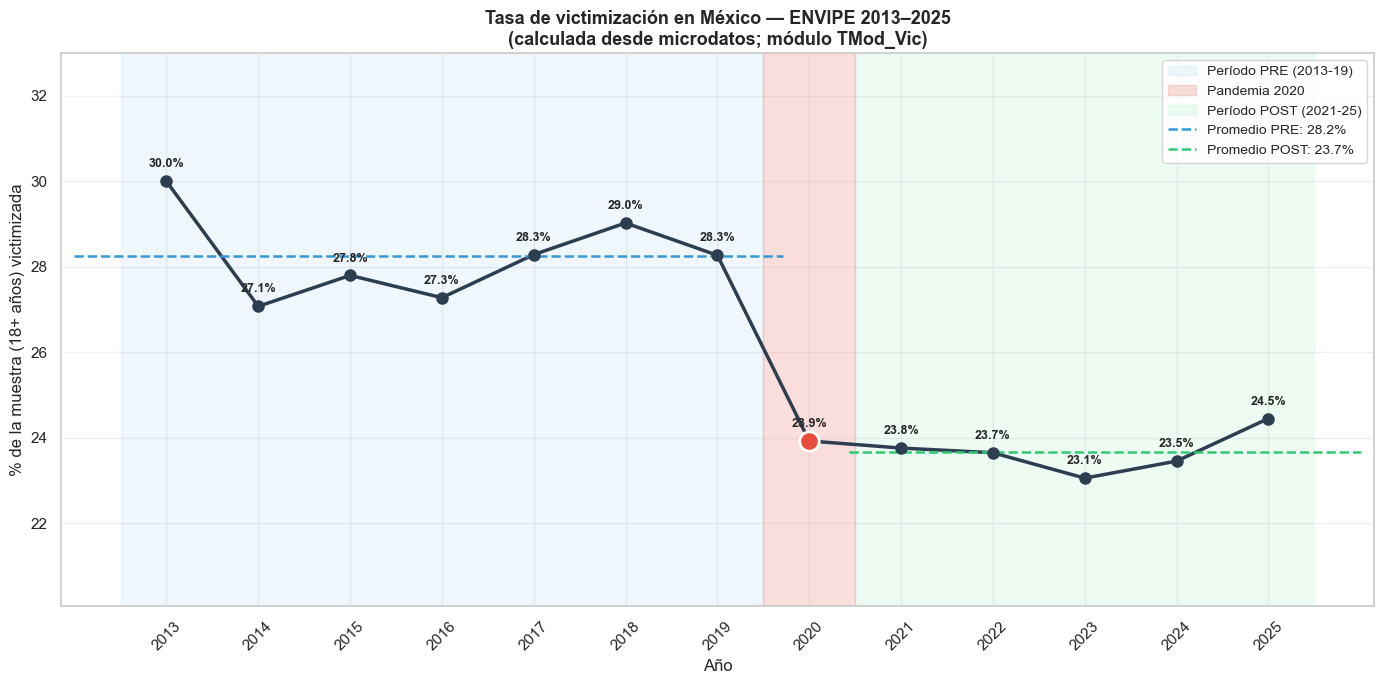

fig01_tasa_nacional.png guardada


In [8]:
# FIGURA 1: Tasa nacional de victimización (desde microdatos)
fig, ax = plt.subplots(figsize=(14, 7))

# Serie calculada desde df_pool (no INEGI hardcoded)
años_s = resumen['año'].tolist()
tasas_s = resumen['tasa'].tolist()

# Promedios por periodo (calculados desde nuestros datos)
prom_pre_m  = resumen[resumen['año'].isin(PERIODO_PRE)]['tasa'].mean()
prom_post_m = resumen[resumen['año'].isin(PERIODO_POST)]['tasa'].mean()

# Zonas sombreadas
ax.axvspan(2012.5, 2019.5, alpha=0.08, color='#3498db', label='Período PRE (2013-19)')
ax.axvspan(2019.5, 2020.5, alpha=0.18, color='#e74c3c', label='Pandemia 2020')
ax.axvspan(2020.5, 2025.5, alpha=0.08, color='#2ecc71', label='Período POST (2021-25)')

# Línea continua
ax.plot(años_s, tasas_s, '-', color='#2c3e50', lw=2.5, zorder=2)

# Puntos: rojo 2020, oscuros el resto
for a, t in zip(años_s, tasas_s):
    if a == 2020:
        ax.plot(a, t, 'o', color='#e74c3c', ms=14, zorder=5,
                markeredgecolor='white', markeredgewidth=2)
    else:
        ax.plot(a, t, 'o', color='#2c3e50', ms=8, zorder=3)
    ax.annotate(f'{t:.1f}%', (a, t), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

# Líneas de promedio
ax.axhline(y=prom_pre_m,  xmin=0.01, xmax=0.55,
           color='#3498db', ls='--', lw=1.8,
           label=f'Promedio PRE: {prom_pre_m:.1f}%')
ax.axhline(y=prom_post_m, xmin=0.60, xmax=0.99,
           color='#2ecc71', ls='--', lw=1.8,
           label=f'Promedio POST: {prom_post_m:.1f}%')

ax.set_title('Tasa de victimización en México — ENVIPE 2013–2025\n'
             '(calculada desde microdatos; módulo TMod_Vic)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% de la muestra (18+ años) victimizada')
ax.set_xlabel('Año')
ax.set_ylim(min(tasas_s)-3, max(tasas_s)+3)
ax.set_xticks(años_s)
ax.set_xticklabels(años_s, rotation=45)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig01_tasa_nacional.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig01_tasa_nacional.png guardada')

---
## Sección 4 — ¿Qué delitos cayeron y cuáles subieron?

La caída agregada es un promedio que oculta heterogeneidad. ENVIPE captura 15 tipos de delito (código `BPCOD` en `TMod_Vic`). Aquí los analizamos por separado.

La hipótesis implícita:
> Si la pandemia alteró la composición del crimen, entonces el perfil de personas en riesgo también cambió — no todos los delitos afectan a las mismas personas.

Esta sección justifica empíricamente por qué modelamos PRE y POST por separado.


In [9]:
# Catálogo de delitos (BPCOD)
DELITOS_CATALOGO = {
    '01': 'Robo total de vehículo',
    '02': 'Robo de accesorios de vehículo',
    '03': 'Vandalismo / grafiti',
    '04': 'Robo en casa habitación',
    '05': 'Robo o asalto en calle/transporte',
    '06': 'Otro robo',
    '07': 'Fraude bancario',
    '08': 'Fraude al consumidor',
    '09': 'Extorsión',
    '10': 'Amenazas verbales',
    '11': 'Lesiones por agresión',
    '12': 'Secuestro',
    '13': 'Hostigamiento sexual',
    '14': 'Violación sexual',
    '15': 'Otros delitos',
}


def cargar_delitos_año(año, cfg):
    '''Carga TMod_Vic y cuenta delitos por BPCOD.'''
    carpeta = os.path.join(BASE_PATH, cfg['carpeta'])
    mod = leer_tabla(carpeta, 'TMod_Vic', cfg['fmt'])
    if mod is None or 'BPCOD' not in mod.columns:
        return None
    mod['BPCOD'] = mod['BPCOD'].astype(str).str.strip().str.zfill(2)

    fac_col = 'FAC_DEL' if 'FAC_DEL' in mod.columns else None
    if fac_col:
        mod[fac_col] = pd.to_numeric(mod[fac_col], errors='coerce').fillna(0)
        r = mod.groupby('BPCOD').agg(
            n_muestra=('BPCOD','size'),
            n_expandido=(fac_col,'sum')
        ).reset_index()
    else:
        r = mod.groupby('BPCOD').size().reset_index(name='n_muestra')
        r['n_expandido'] = np.nan
    r['año'] = año
    return r


print('Cargando delitos por tipo y año...')
dfs_d = []
for año in TODOS_ANOS:
    r = cargar_delitos_año(año, ENVIPE_CONFIG[año])
    if r is not None:
        dfs_d.append(r)
        print(f'  {año}  {r["n_muestra"].sum():>7,} delitos  ({len(r)} tipos)')

df_delitos = pd.concat(dfs_d, ignore_index=True)
df_delitos['delito_nombre'] = df_delitos['BPCOD'].map(DELITOS_CATALOGO)
df_delitos['valor'] = df_delitos['n_expandido'].fillna(df_delitos['n_muestra'])
print(f'\nTotal: {len(df_delitos):,} filas (tipo × año)')

Cargando delitos por tipo y año...
  2013   47,117 delitos  (15 tipos)
  2014   43,478 delitos  (15 tipos)
  2015   44,699 delitos  (15 tipos)
  2016   40,026 delitos  (15 tipos)
  2017   44,630 delitos  (15 tipos)
  2018   46,674 delitos  (15 tipos)
  2019   46,356 delitos  (15 tipos)
  2020   38,575 delitos  (15 tipos)
  2021   37,156 delitos  (15 tipos)
  2022   36,144 delitos  (15 tipos)
  2023   35,135 delitos  (15 tipos)
  2024   37,614 delitos  (15 tipos)
  2025   40,280 delitos  (15 tipos)

Total: 195 filas (tipo × año)


### 4.1 Tabla comparativa PRE → POST por tipo de delito

Ordenados de mayor caída a mayor alza. El patrón no es aleatorio: sigue una lógica de exposición y movilidad.


In [10]:
# Tabla de cambios PRE-POST por delito
df_pre_d  = df_delitos[df_delitos['año'].isin(PERIODO_PRE)]
df_post_d = df_delitos[df_delitos['año'].isin(PERIODO_POST)]

tab_pre = df_pre_d.groupby(['BPCOD','delito_nombre'])['valor'].mean().reset_index()
tab_pre.columns = ['BPCOD','delito','promedio_PRE']
tab_post = df_post_d.groupby('BPCOD')['valor'].mean().reset_index()
tab_post.columns = ['BPCOD','promedio_POST']

tabla_delitos = tab_pre.merge(tab_post, on='BPCOD')
tabla_delitos['cambio_abs'] = tabla_delitos['promedio_POST'] - tabla_delitos['promedio_PRE']
tabla_delitos['cambio_pct'] = (tabla_delitos['promedio_POST']/tabla_delitos['promedio_PRE']-1)*100
tabla_delitos = tabla_delitos.sort_values('cambio_pct').reset_index(drop=True)

print('='*85)
print('CAMBIO EN INCIDENCIA POR TIPO DE DELITO: PRE (2013-19) vs POST (2021-25)')
print('='*85)
print(f'{"Delito":<40} {"PRE":>12} {"POST":>12} {"Δ%":>8}')
print('-'*85)
for _, r in tabla_delitos.iterrows():
    if r['cambio_pct'] < -10:
        flag = '(caída)'
    elif r['cambio_pct'] > 10:
        flag = '(alza)'
    else:
        flag = ''
    print(f'{r["delito"][:39]:<40} {r["promedio_PRE"]:>12,.0f} '
          f'{r["promedio_POST"]:>12,.0f} {r["cambio_pct"]:>+7.1f}%  {flag}')

CAMBIO EN INCIDENCIA POR TIPO DE DELITO: PRE (2013-19) vs POST (2021-25)
Delito                                            PRE         POST       Δ%
-------------------------------------------------------------------------------------
Vandalismo / grafiti                        3,253,674    1,954,642   -39.9%  (caída)
Robo o asalto en calle/transporte           8,933,146    5,889,898   -34.1%  (caída)
Extorsión                                   6,952,727    4,983,986   -28.3%  (caída)
Robo en casa habitación                     2,144,240    1,630,733   -23.9%  (caída)
Robo de accesorios de vehículo              3,197,594    2,537,576   -20.6%  (caída)
Secuestro                                      76,998       61,785   -19.8%  (caída)
Robo total de vehículo                        563,758      489,712   -13.1%  (caída)
Otro robo                                   1,234,618    1,337,531    +8.3%  
Amenazas verbales                           2,805,850    3,128,135   +11.5%  (alza)
Lesiones

### 4.2 Figura 2 — Evolución temporal por tipo de delito

15 paneles, uno por delito, con 2020 destacado en rojo. Permite distinguir:

- **Efecto shock transitorio:** el delito cae en 2020 pero se recupera después.
- **Cambio estructural persistente:** el delito cae y sigue bajo en POST.


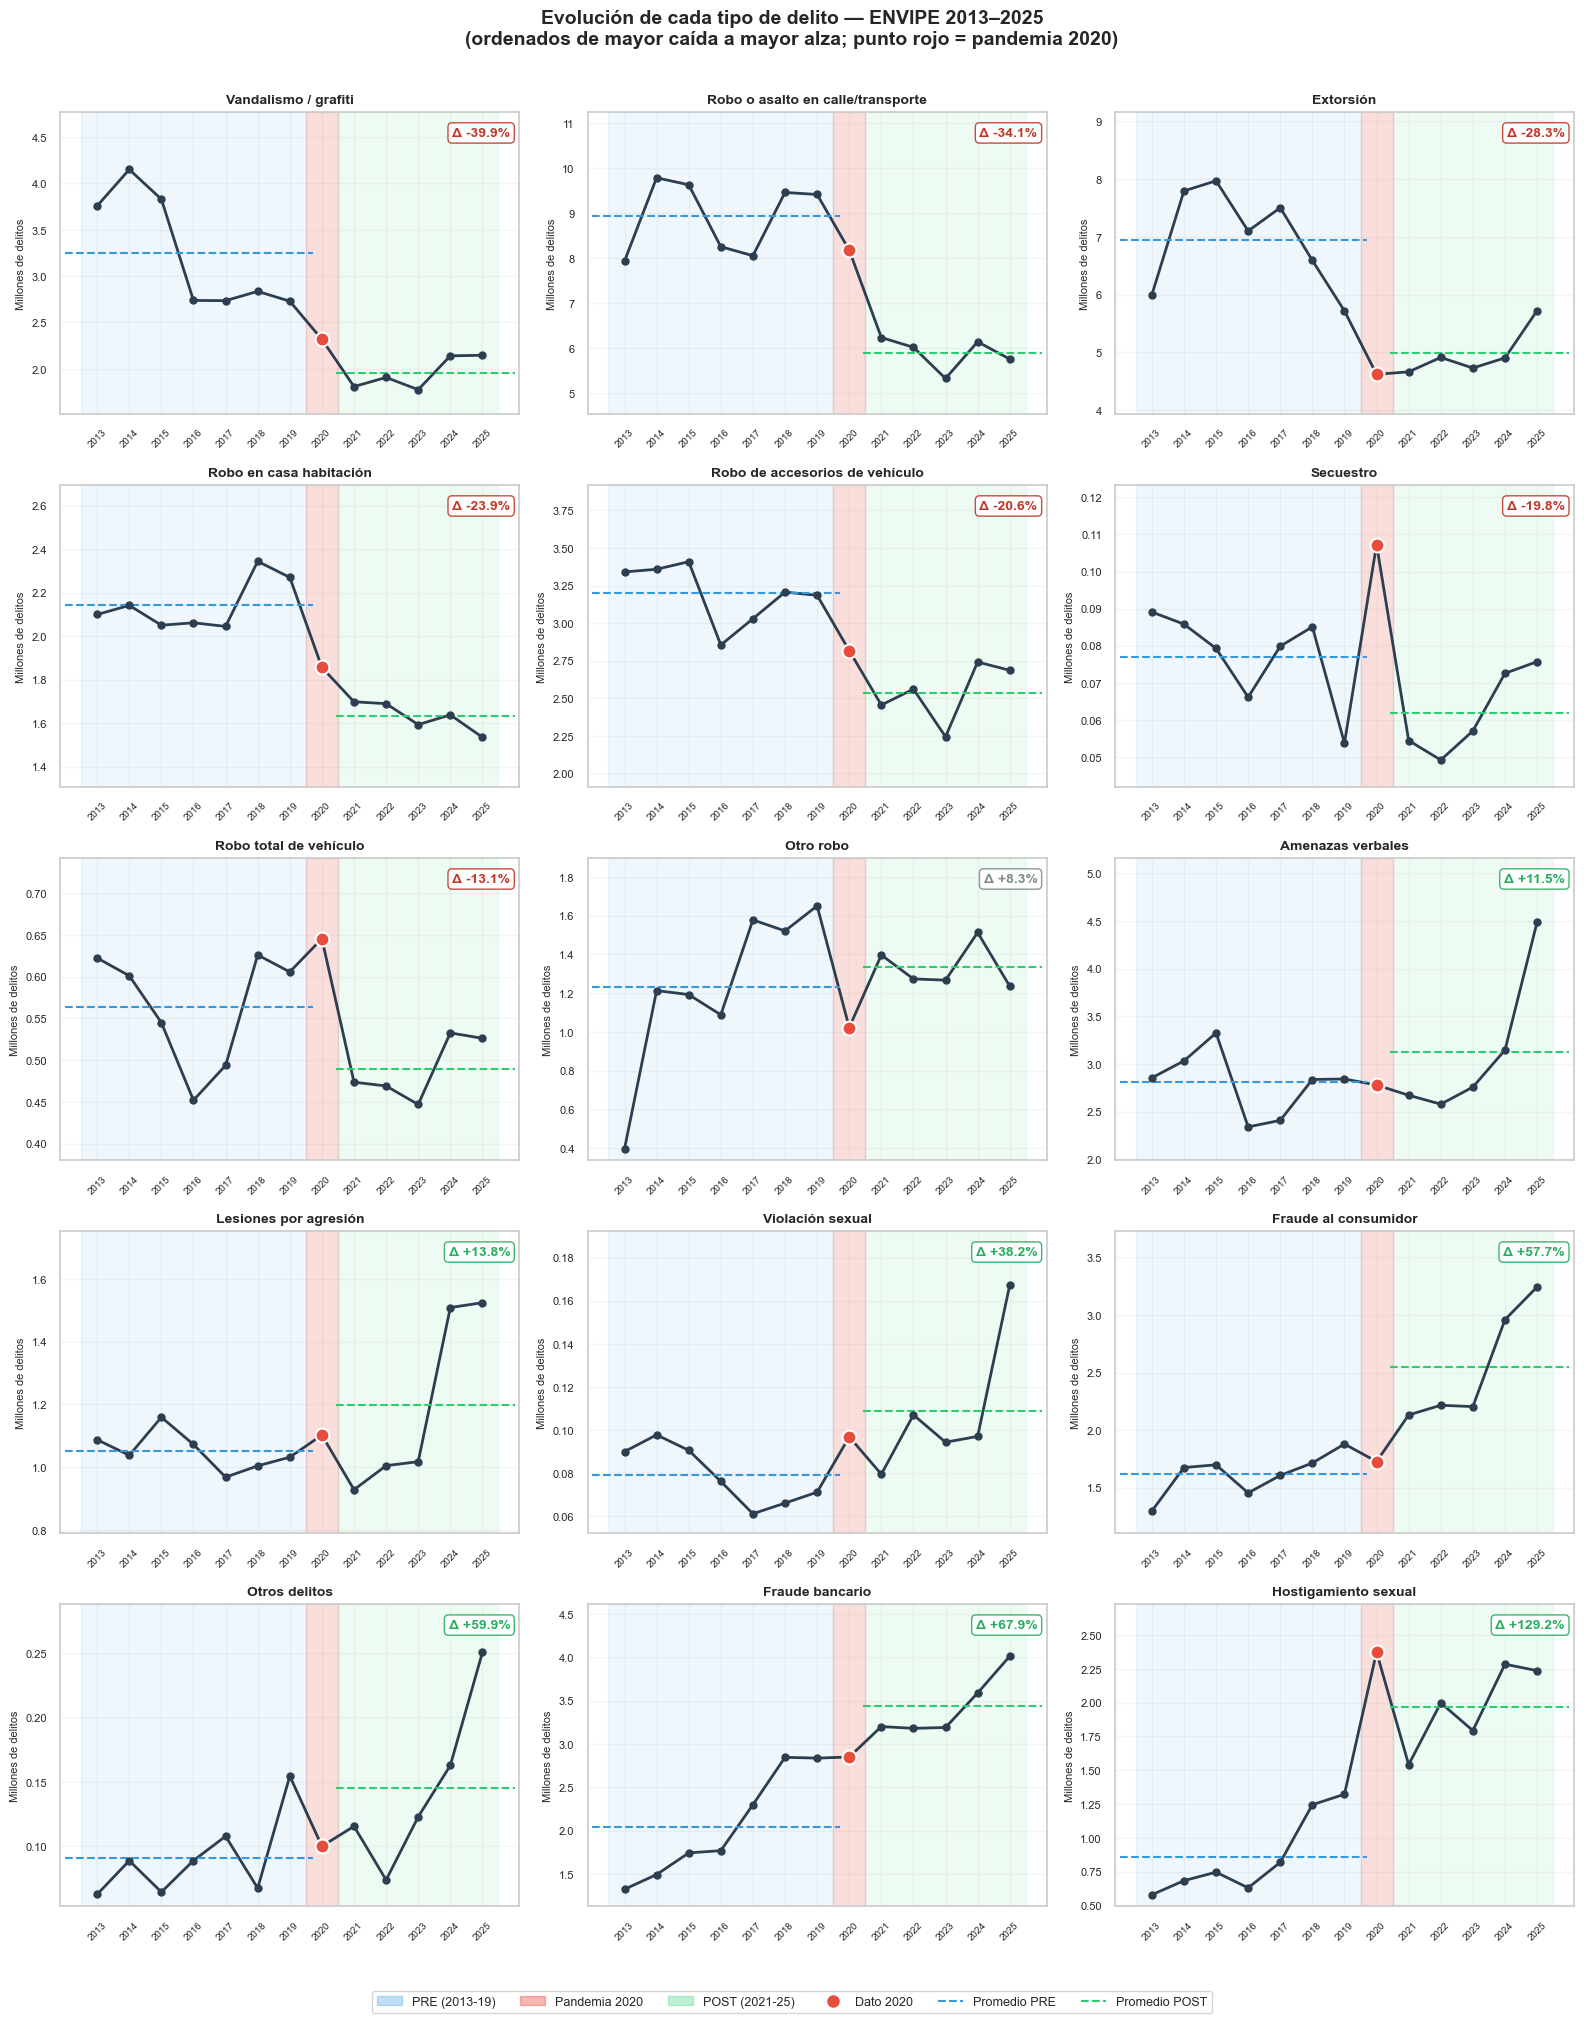

fig02_series_por_delito.png guardada


In [11]:
# FIGURA 2: Serie temporal por tipo de delito (15 paneles)
pivot_serie = df_delitos.pivot(index='año', columns='delito_nombre', values='valor')
orden_delitos = tabla_delitos['delito'].tolist()

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
fig.suptitle('Evolución de cada tipo de delito — ENVIPE 2013–2025\n'
             '(ordenados de mayor caída a mayor alza; punto rojo = pandemia 2020)',
             fontsize=14, fontweight='bold', y=0.995)

axes_flat = axes.flatten()
años_f = sorted(pivot_serie.index.tolist())

for i, delito in enumerate(orden_delitos):
    ax = axes_flat[i]
    serie = pivot_serie[delito] / 1e6

    prom_p  = serie[serie.index.isin(PERIODO_PRE)].mean()
    prom_po = serie[serie.index.isin(PERIODO_POST)].mean()
    cambio = (prom_po/prom_p - 1) * 100

    y_min = serie.min() * 0.85
    y_max = serie.max() * 1.15

    ax.axvspan(2012.5, 2019.5, alpha=0.08, color='#3498db')
    ax.axvspan(2019.5, 2020.5, alpha=0.18, color='#e74c3c')
    ax.axvspan(2020.5, 2025.5, alpha=0.08, color='#2ecc71')

    valores = [serie[a] for a in años_f]
    ax.plot(años_f, valores, '-', color='#2c3e50', lw=2, zorder=2)
    for a, v in zip(años_f, valores):
        if a == 2020:
            ax.plot(a, v, 'o', color='#e74c3c', ms=10, zorder=5,
                    markeredgecolor='white', markeredgewidth=1.5)
        else:
            ax.plot(a, v, 'o', color='#2c3e50', ms=5, zorder=3)

    ax.axhline(y=prom_p,  xmin=0.01, xmax=0.55, color='#3498db', ls='--', lw=1.5)
    ax.axhline(y=prom_po, xmin=0.60, xmax=0.99, color='#2ecc71', ls='--', lw=1.5)

    color_c = '#c0392b' if cambio<-10 else ('#27ae60' if cambio>10 else '#7f8c8d')
    ax.text(0.98, 0.95, f'Δ {cambio:+.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, fontweight='bold',
            color=color_c,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color_c, alpha=0.9))

    ax.set_title(delito, fontsize=10, fontweight='bold')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(años_f)
    ax.set_xticklabels(años_f, rotation=45, fontsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel('Millones de delitos', fontsize=8)
    ax.grid(True, alpha=0.2)

parches = [
    mpatches.Patch(color='#3498db', alpha=0.3, label='PRE (2013-19)'),
    mpatches.Patch(color='#e74c3c', alpha=0.4, label='Pandemia 2020'),
    mpatches.Patch(color='#2ecc71', alpha=0.3, label='POST (2021-25)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=10, label='Dato 2020'),
    plt.Line2D([0],[0], color='#3498db', ls='--', lw=1.5, label='Promedio PRE'),
    plt.Line2D([0],[0], color='#2ecc71', ls='--', lw=1.5, label='Promedio POST'),
]
fig.legend(handles=parches, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.savefig('fig02_series_por_delito.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig02_series_por_delito.png guardada')

### 4.3 Interpretación

Los datos muestran un patrón sistemático:

- **Delitos con convergencia física víctima-ofensor en espacio público** (robos patrimoniales, vandalismo, extorsión, secuestro) cayeron entre 13% y 40%.
- **Delitos con características distintas** (fraudes digitales, hostigamiento, amenazas, lesiones) subieron entre 8% y 129%.

**Consecuencia analítica:** si los delitos cambiaron de composición, el perfil de las víctimas también debió cambiar. Quien tenía alto riesgo en 2015 no necesariamente lo tiene en 2024.

**Caveat para limitaciones:** los aumentos grandes en fraudes y delitos sexuales probablemente reflejan una mezcla de cambio real y cambio en disposición a reportar.


---
## Sección 5 — Perfil descriptivo de las víctimas

Antes de modelar, exploramos si las tasas de victimización cambiaron por subgrupo sociodemográfico. Todas las tasas se calculan desde `df_pool`.


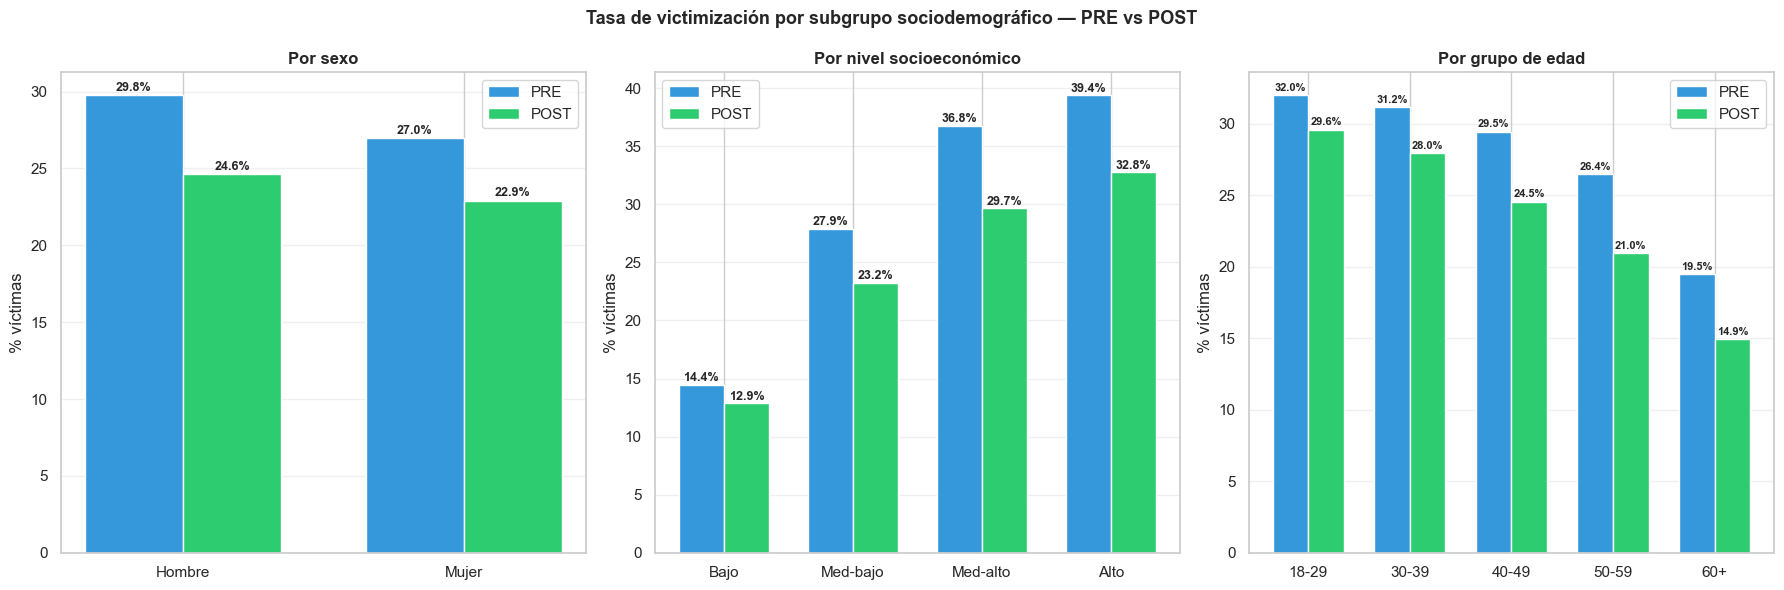

fig03_perfil_descriptivo.png guardada


In [12]:
# FIGURA 3: Perfil descriptivo PRE vs POST por subgrupo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Tasa de victimización por subgrupo sociodemográfico — PRE vs POST',
             fontsize=13, fontweight='bold')

df_pp = df_pool[df_pool['periodo'].isin(['PRE','POST'])].copy()

# Panel 1: Por sexo
if 'SEXO' in df_pp.columns:
    df_pp['SEXO'] = pd.to_numeric(df_pp['SEXO'], errors='coerce')
    t_sx = df_pp.groupby(['periodo','SEXO'])['victima'].mean().mul(100).reset_index()
    p_sx = t_sx.pivot(index='SEXO', columns='periodo', values='victima')
    p_sx.index = p_sx.index.map({1:'Hombre', 2:'Mujer'})
    x = np.arange(len(p_sx))
    w = 0.35
    axes[0].bar(x-w/2, p_sx['PRE'],  w, color='#3498db', label='PRE', edgecolor='white')
    axes[0].bar(x+w/2, p_sx['POST'], w, color='#2ecc71', label='POST', edgecolor='white')
    for i, (pre, post) in enumerate(zip(p_sx['PRE'], p_sx['POST'])):
        axes[0].text(i-w/2, pre+0.3,  f'{pre:.1f}%',  ha='center', fontsize=9, fontweight='bold')
        axes[0].text(i+w/2, post+0.3, f'{post:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(p_sx.index)
    axes[0].set_title('Por sexo', fontweight='bold')
    axes[0].set_ylabel('% víctimas')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Por NSE
if 'ESTRATO' in df_pp.columns:
    df_pp['ESTRATO'] = pd.to_numeric(df_pp['ESTRATO'], errors='coerce')
    t_ns = df_pp.groupby(['periodo','ESTRATO'])['victima'].mean().mul(100).reset_index()
    p_ns = t_ns.pivot(index='ESTRATO', columns='periodo', values='victima')
    p_ns = p_ns.dropna()
    p_ns.index = p_ns.index.map({1:'Bajo', 2:'Med-bajo', 3:'Med-alto', 4:'Alto'})
    p_ns = p_ns.reindex([x for x in ['Bajo','Med-bajo','Med-alto','Alto'] if x in p_ns.index])
    x = np.arange(len(p_ns))
    w = 0.35
    axes[1].bar(x-w/2, p_ns['PRE'],  w, color='#3498db', label='PRE', edgecolor='white')
    axes[1].bar(x+w/2, p_ns['POST'], w, color='#2ecc71', label='POST', edgecolor='white')
    for i, (pre, post) in enumerate(zip(p_ns['PRE'], p_ns['POST'])):
        axes[1].text(i-w/2, pre+0.3,  f'{pre:.1f}%',  ha='center', fontsize=9, fontweight='bold')
        axes[1].text(i+w/2, post+0.3, f'{post:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(p_ns.index)
    axes[1].set_title('Por nivel socioeconómico', fontweight='bold')
    axes[1].set_ylabel('% víctimas')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Por grupo de edad
if 'EDAD' in df_pp.columns:
    df_pp['EDAD'] = pd.to_numeric(df_pp['EDAD'], errors='coerce')
    df_pp['grupo_edad'] = pd.cut(df_pp['EDAD'], bins=[17,29,39,49,59,100],
                                 labels=['18-29','30-39','40-49','50-59','60+'])
    t_ed = df_pp.groupby(['periodo','grupo_edad'])['victima'].mean().mul(100).reset_index()
    p_ed = t_ed.pivot(index='grupo_edad', columns='periodo', values='victima')
    p_ed = p_ed.dropna()
    x = np.arange(len(p_ed))
    w = 0.35
    axes[2].bar(x-w/2, p_ed['PRE'],  w, color='#3498db', label='PRE', edgecolor='white')
    axes[2].bar(x+w/2, p_ed['POST'], w, color='#2ecc71', label='POST', edgecolor='white')
    for i, (pre, post) in enumerate(zip(p_ed['PRE'], p_ed['POST'])):
        axes[2].text(i-w/2, pre+0.3,  f'{pre:.1f}%',  ha='center', fontsize=8, fontweight='bold')
        axes[2].text(i+w/2, post+0.3, f'{post:.1f}%', ha='center', fontsize=8, fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(p_ed.index)
    axes[2].set_title('Por grupo de edad', fontweight='bold')
    axes[2].set_ylabel('% víctimas')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig03_perfil_descriptivo.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig03_perfil_descriptivo.png guardada')

---
## Sección 6 — Preparación de variables predictivas

El modelo usa 20 features en 5 grupos:

1. **Sociodemográficos básicos:** sexo, edad, grupo de edad, estrato (NSE), nivel educativo, situación laboral.
2. **Percepción de seguridad:** percepción en colonia y en municipio.
3. **Entorno del barrio:** 7 indicadores binarios (pandillerismo, drogas, robos, disparos, secuestros, extorsiones).
4. **Conducta preventiva:** si dejó de salir de noche o de caminar solo por temor.
5. **Tendencia temporal:** año como variable continua.

Además construimos dos features compuestas: `indice_zona` (promedio de problemas del barrio) y `conducta_preventiva` (indicador binario).


In [13]:
# Preparar df_model solo con PRE y POST (excluir 2020)
df_model = df_pool[df_pool['periodo'].isin(['PRE','POST'])].copy()

# 1) Limpiar códigos 'no sabe/no responde' en ordinales
cols_limpiar = ['SEXO','ESTRATO','NIV','AP3_8',
                'AP4_3_1','AP4_3_2',
                'AP4_5_02','AP4_5_08','AP4_5_09','AP4_5_10',
                'AP4_5_11','AP4_5_13','AP4_5_15',
                'AP4_10_01','AP4_10_09']
for col in cols_limpiar:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
        df_model[col] = df_model[col].replace({9:np.nan, 99:np.nan, 8:np.nan, 88:np.nan})

# 2) Edad — códigos 97/98/99 son no especificado
if 'EDAD' in df_model.columns:
    df_model['EDAD'] = pd.to_numeric(df_model['EDAD'], errors='coerce')
    df_model['EDAD'] = df_model['EDAD'].replace({97:np.nan, 98:np.nan, 99:np.nan})

# 3) Índice de problemas en zona
cols_zona = [c for c in ['AP4_5_02','AP4_5_08','AP4_5_09','AP4_5_10',
                         'AP4_5_11','AP4_5_13','AP4_5_15']
             if c in df_model.columns]
for col in cols_zona:
    df_model[col] = (df_model[col] == 1).astype(float)
df_model['indice_zona'] = df_model[cols_zona].mean(axis=1)

# 4) Conducta preventiva
cols_prev = [c for c in ['AP4_10_01','AP4_10_09'] if c in df_model.columns]
for col in cols_prev:
    df_model[col] = (df_model[col] == 1).astype(float)
df_model['conducta_preventiva'] = df_model[cols_prev].max(axis=1)

# 5) Grupo de edad numérico
df_model['grupo_edad_num'] = pd.cut(
    df_model['EDAD'], bins=[17,29,39,49,59,100],
    labels=[1,2,3,4,5]).astype(float)

# 6) Año como continuo
df_model['año_num'] = df_model['año'].astype(float)

# 7) POST binario (para interacciones)
df_model['POST'] = (df_model['periodo'] == 'POST').astype(int)

# Lista final de features
FEATURES = [
    'SEXO', 'EDAD', 'grupo_edad_num', 'ESTRATO', 'NIV', 'AP3_8',
    'AP4_3_1', 'AP4_3_2',
    'AP4_5_02', 'AP4_5_08', 'AP4_5_09', 'AP4_5_10',
    'AP4_5_11', 'AP4_5_13', 'AP4_5_15',
    'AP4_10_01', 'AP4_10_09',
    'indice_zona', 'conducta_preventiva',
    'año_num',
]

# Etiquetas legibles
ETIQUETAS = {
    'SEXO': 'Sexo (mujer=2)',
    'EDAD': 'Edad',
    'grupo_edad_num': 'Grupo de edad',
    'ESTRATO': 'Nivel socioeconómico',
    'NIV': 'Nivel educativo',
    'AP3_8': 'Situación laboral',
    'AP4_3_1': 'Percepción inseguridad (colonia)',
    'AP4_3_2': 'Percepción inseguridad (municipio)',
    'AP4_5_02': 'Pandillerismo en zona',
    'AP4_5_08': 'Consumo de drogas en zona',
    'AP4_5_09': 'Robos frecuentes en zona',
    'AP4_5_10': 'Venta de drogas en zona',
    'AP4_5_11': 'Disparos frecuentes',
    'AP4_5_13': 'Secuestros en zona',
    'AP4_5_15': 'Extorsiones en zona',
    'AP4_10_01': 'Dejó de salir de noche',
    'AP4_10_09': 'Dejó de caminar solo',
    'indice_zona': 'Índice problemas en zona',
    'conducta_preventiva': 'Conducta preventiva',
    'año_num': 'Año (tendencia temporal)',
}

print(f'FEATURES DISPONIBLES ({len(FEATURES)}):')
print('-'*65)
for f in FEATURES:
    if f in df_model.columns:
        na = df_model[f].isna().sum()
        pct = na/len(df_model)*100
        print(f'  {f:<22} {na:>7,} nulos ({pct:5.1f}%)  {ETIQUETAS.get(f,f)}')

FEATURES DISPONIBLES (20):
-----------------------------------------------------------------
  SEXO                         0 nulos (  0.0%)  Sexo (mujer=2)
  EDAD                     5,669 nulos (  0.5%)  Edad
  grupo_edad_num           5,669 nulos (  0.5%)  Grupo de edad
  ESTRATO                167,562 nulos ( 15.6%)  Nivel socioeconómico
  NIV                    220,825 nulos ( 20.6%)  Nivel educativo
  AP3_8                   42,836 nulos (  4.0%)  Situación laboral
  AP4_3_1                  3,953 nulos (  0.4%)  Percepción inseguridad (colonia)
  AP4_3_2                 13,719 nulos (  1.3%)  Percepción inseguridad (municipio)
  AP4_5_02                     0 nulos (  0.0%)  Pandillerismo en zona
  AP4_5_08                     0 nulos (  0.0%)  Consumo de drogas en zona
  AP4_5_09                     0 nulos (  0.0%)  Robos frecuentes en zona
  AP4_5_10                     0 nulos (  0.0%)  Venta de drogas en zona
  AP4_5_11                     0 nulos (  0.0%)  Disparos frecuen

---
## Sección 7 — Modelo predictivo PRE-pandemia (2013–2019)

Cuatro clasificadores binarios, misma pipeline: imputación mediana + SMOTE + estandarización + clasificador. Métrica principal: AUC-ROC.


In [14]:
# Dataset PRE
df_pre = df_model[df_model['periodo'] == 'PRE'].copy()
X_pre = df_pre[FEATURES].copy()
y_pre = df_pre['victima'].copy()

# Eliminar features que son 100% NaN en PRE
nan_100_pre = [f for f in FEATURES if X_pre[f].isna().all()]
FEATURES_PRE = [f for f in FEATURES if f not in nan_100_pre]
X_pre = X_pre[FEATURES_PRE]

X_pre_tr, X_pre_te, y_pre_tr, y_pre_te = train_test_split(
    X_pre, y_pre, test_size=0.25, random_state=RANDOM_STATE, stratify=y_pre)

print(f'Dataset PRE:')
print(f'  Observaciones: {len(df_pre):,}')
print(f'  Tasa victimización: {y_pre.mean()*100:.1f}%')
print(f'  Train: {len(X_pre_tr):,}  Test: {len(X_pre_te):,}')
print(f'  Features: {len(FEATURES_PRE)}')


def hacer_pipeline(modelo):
    return ImbPipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('smt', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ('scl', StandardScaler()),
        ('clf', modelo),
    ])

def definir_modelos(y_train):
    spw = (y_train==0).sum() / (y_train==1).sum()
    return {
        'Regresión Logística': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            scale_pos_weight=spw, eval_metric='auc',
            random_state=RANDOM_STATE, verbosity=0),
    }


print('\nEntrenando modelos PRE...')
resultados_pre = {}
for nombre, modelo in definir_modelos(y_pre_tr).items():
    pipe = hacer_pipeline(modelo)
    pipe.fit(X_pre_tr, y_pre_tr)
    y_prob = pipe.predict_proba(X_pre_te)[:,1]
    y_pred = pipe.predict(X_pre_te)
    auc = roc_auc_score(y_pre_te, y_prob)
    ap  = average_precision_score(y_pre_te, y_prob)
    resultados_pre[nombre] = {'pipe':pipe,'y_prob':y_prob,'y_pred':y_pred,'AUC':auc,'AP':ap}
    print(f'  {nombre:<25} AUC={auc:.4f}  AP={ap:.4f}')

mejor_pre = max(resultados_pre, key=lambda k: resultados_pre[k]['AUC'])
print(f'\nMejor modelo PRE: {mejor_pre} (AUC={resultados_pre[mejor_pre]["AUC"]:.4f})')

Dataset PRE:
  Observaciones: 613,801
  Tasa victimización: 28.3%
  Train: 460,350  Test: 153,451
  Features: 20

Entrenando modelos PRE...
  Regresión Logística       AUC=0.7144  AP=0.4797
  Random Forest             AUC=0.7177  AP=0.4801
  Gradient Boosting         AUC=0.7209  AP=0.4894
  XGBoost                   AUC=0.7205  AP=0.4893

Mejor modelo PRE: Gradient Boosting (AUC=0.7209)


### 7.1 Importancia de variables — Modelo PRE

In [15]:
# Importancia de variables del mejor modelo PRE
pipe_pre = resultados_pre[mejor_pre]['pipe']
try:
    FEATURES_PRE_REAL = list(pipe_pre.named_steps['imp'].feature_names_in_)
except Exception:
    FEATURES_PRE_REAL = FEATURES_PRE.copy()

clf_pre = pipe_pre.named_steps['clf']
if hasattr(clf_pre, 'feature_importances_'):
    imp_pre = pd.Series(clf_pre.feature_importances_, index=FEATURES_PRE_REAL)
elif hasattr(clf_pre, 'coef_'):
    imp_pre = pd.Series(np.abs(clf_pre.coef_[0]), index=FEATURES_PRE_REAL)
imp_pre = imp_pre.sort_values(ascending=False)

imp_pre_label = imp_pre.copy()
imp_pre_label.index = [ETIQUETAS.get(i, i) for i in imp_pre_label.index]

print(f'IMPORTANCIA DE VARIABLES — {mejor_pre} (PRE)')
print('='*65)
for feat, val in imp_pre_label.items():
    barra = '#' * int(val * 200)
    print(f'  {feat:<35} {val:.4f}  {barra}')

IMPORTANCIA DE VARIABLES — Gradient Boosting (PRE)
  Nivel educativo                     0.1715  ##################################
  Índice problemas en zona            0.1686  #################################
  Robos frecuentes en zona            0.1122  ######################
  Nivel socioeconómico                0.0871  #################
  Percepción inseguridad (colonia)    0.0794  ###############
  Dejó de caminar solo                0.0628  ############
  Año (tendencia temporal)            0.0574  ###########
  Dejó de salir de noche              0.0529  ##########
  Sexo (mujer=2)                      0.0491  #########
  Percepción inseguridad (municipio)  0.0436  ########
  Extorsiones en zona                 0.0253  #####
  Pandillerismo en zona               0.0214  ####
  Situación laboral                   0.0160  ###
  Disparos frecuentes                 0.0142  ##
  Consumo de drogas en zona           0.0121  ##
  Edad                                0.0100  ##
  Secues

---
## Sección 8 — Modelo predictivo POST-pandemia (2021–2025)

Misma pipeline que PRE. Comparabilidad metodológica garantizada.


In [16]:
# Dataset POST
df_post = df_model[df_model['periodo'] == 'POST'].copy()
X_post = df_post[FEATURES].copy()
y_post = df_post['victima'].copy()

nan_100_post = [f for f in FEATURES if X_post[f].isna().all()]
FEATURES_POST = [f for f in FEATURES if f not in nan_100_post]
X_post = X_post[FEATURES_POST]

X_post_tr, X_post_te, y_post_tr, y_post_te = train_test_split(
    X_post, y_post, test_size=0.25, random_state=RANDOM_STATE, stratify=y_post)

print(f'Dataset POST:')
print(f'  Observaciones: {len(df_post):,}')
print(f'  Tasa victimización: {y_post.mean()*100:.1f}%')
print(f'  Train: {len(X_post_tr):,}  Test: {len(X_post_te):,}')
print(f'  Features: {len(FEATURES_POST)}')

print('\nEntrenando modelos POST...')
resultados_post = {}
for nombre, modelo in definir_modelos(y_post_tr).items():
    pipe = hacer_pipeline(modelo)
    pipe.fit(X_post_tr, y_post_tr)
    y_prob = pipe.predict_proba(X_post_te)[:,1]
    y_pred = pipe.predict(X_post_te)
    auc = roc_auc_score(y_post_te, y_prob)
    ap  = average_precision_score(y_post_te, y_prob)
    resultados_post[nombre] = {'pipe':pipe,'y_prob':y_prob,'y_pred':y_pred,'AUC':auc,'AP':ap}
    print(f'  {nombre:<25} AUC={auc:.4f}  AP={ap:.4f}')

mejor_post = max(resultados_post, key=lambda k: resultados_post[k]['AUC'])
print(f'\nMejor modelo POST: {mejor_post} (AUC={resultados_post[mejor_post]["AUC"]:.4f})')

Dataset POST:
  Observaciones: 456,950
  Tasa victimización: 23.7%
  Train: 342,712  Test: 114,238
  Features: 20

Entrenando modelos POST...
  Regresión Logística       AUC=0.7273  AP=0.4363
  Random Forest             AUC=0.7294  AP=0.4355
  Gradient Boosting         AUC=0.7321  AP=0.4449
  XGBoost                   AUC=0.7320  AP=0.4450

Mejor modelo POST: Gradient Boosting (AUC=0.7321)


### 8.1 Importancia de variables — Modelo POST

In [17]:
# Importancia POST
pipe_post = resultados_post[mejor_post]['pipe']
try:
    FEATURES_POST_REAL = list(pipe_post.named_steps['imp'].feature_names_in_)
except Exception:
    FEATURES_POST_REAL = FEATURES_POST.copy()

clf_post = pipe_post.named_steps['clf']
if hasattr(clf_post, 'feature_importances_'):
    imp_post = pd.Series(clf_post.feature_importances_, index=FEATURES_POST_REAL)
elif hasattr(clf_post, 'coef_'):
    imp_post = pd.Series(np.abs(clf_post.coef_[0]), index=FEATURES_POST_REAL)
imp_post = imp_post.sort_values(ascending=False)

imp_post_label = imp_post.copy()
imp_post_label.index = [ETIQUETAS.get(i, i) for i in imp_post_label.index]

print(f'IMPORTANCIA DE VARIABLES — {mejor_post} (POST)')
print('='*65)
for feat, val in imp_post_label.items():
    barra = '#' * int(val * 200)
    print(f'  {feat:<35} {val:.4f}  {barra}')

IMPORTANCIA DE VARIABLES — Gradient Boosting (POST)
  Robos frecuentes en zona            0.1387  ###########################
  Nivel socioeconómico                0.1343  ##########################
  Índice problemas en zona            0.1310  ##########################
  Nivel educativo                     0.1178  #######################
  Dejó de salir de noche              0.0653  #############
  Dejó de caminar solo                0.0630  ############
  Sexo (mujer=2)                      0.0590  ###########
  Percepción inseguridad (colonia)    0.0579  ###########
  Año (tendencia temporal)            0.0478  #########
  Percepción inseguridad (municipio)  0.0443  ########
  Extorsiones en zona                 0.0276  #####
  Consumo de drogas en zona           0.0241  ####
  Pandillerismo en zona               0.0198  ###
  Disparos frecuentes                 0.0175  ###
  Edad                                0.0174  ###
  Situación laboral                   0.0173  ###
  Secuest

---
## Sección 8b — Análisis SHAP: dirección y magnitud de efectos (nuevo v_final)

Los `feature_importances_` del Gradient Boosting solo reportan magnitud, no dirección. Los SHAP values descomponen cada predicción en la contribución de cada variable, mostrando no solo cuánto importa cada feature, sino **en qué dirección empuja**.

Esto permite responder preguntas como: ¿mayor NSE *reduce* o *aumenta* la probabilidad de victimización? ¿Esa relación cambió entre PRE y POST?


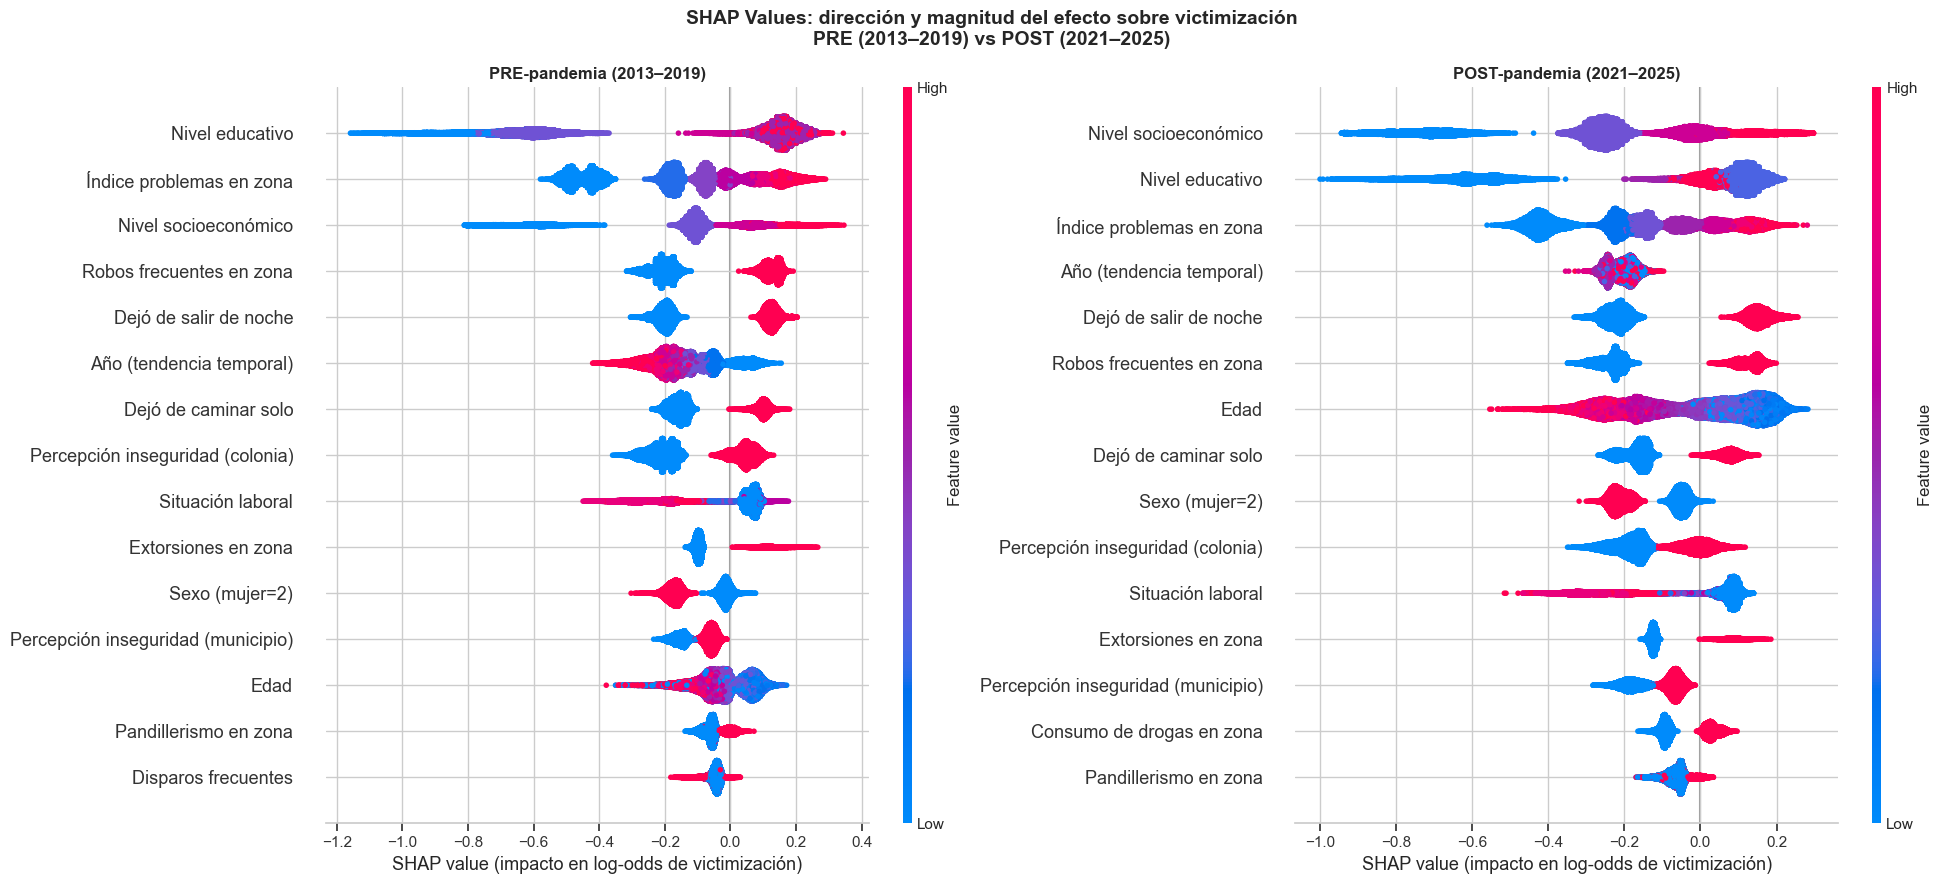

fig_shap_pre_post.png guardada


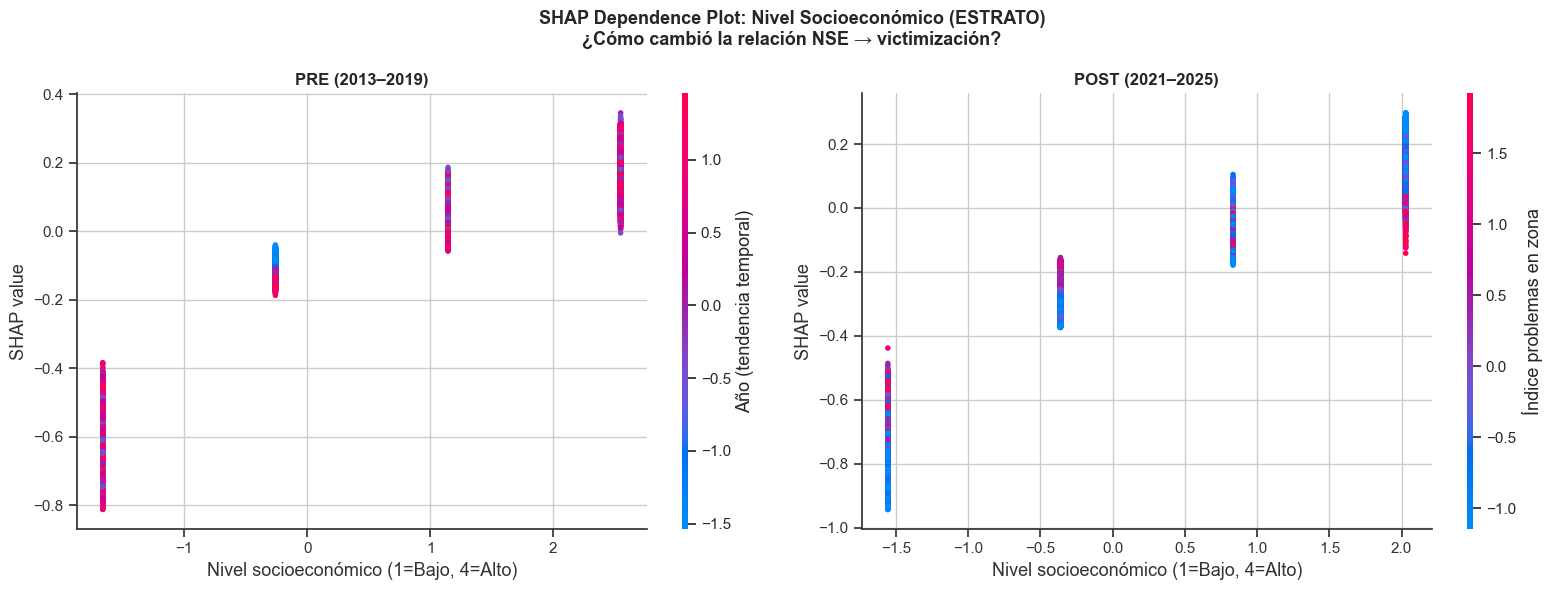

fig_shap_estrato.png guardada


In [18]:
# SHAP Analysis — PRE vs POST
if SHAP_OK:
    import shap
    
    # PRE SHAP
    clf_pre_shap = pipe_pre.named_steps['clf']
    X_pre_transformed = pipe_pre[:-1].transform(X_pre_te)
    
    explainer_pre = shap.TreeExplainer(clf_pre_shap)
    shap_pre = explainer_pre.shap_values(X_pre_transformed)
    
    # POST SHAP
    clf_post_shap = pipe_post.named_steps['clf']
    X_post_transformed = pipe_post[:-1].transform(X_post_te)
    
    explainer_post = shap.TreeExplainer(clf_post_shap)
    shap_post = explainer_post.shap_values(X_post_transformed)
    
    # Usar las features reales
    feat_names_pre = [ETIQUETAS.get(f, f) for f in FEATURES_PRE_REAL]
    feat_names_post = [ETIQUETAS.get(f, f) for f in FEATURES_POST_REAL]
    
    # FIGURA SHAP — Summary plot PRE vs POST
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle('SHAP Values: dirección y magnitud del efecto sobre victimización\n'
                 'PRE (2013–2019) vs POST (2021–2025)',
                 fontsize=14, fontweight='bold')
    
    plt.sca(axes[0])
    shap.summary_plot(shap_pre, X_pre_transformed,
                      feature_names=feat_names_pre,
                      show=False, max_display=15, plot_size=None)
    axes[0].set_title('PRE-pandemia (2013–2019)', fontweight='bold')
    axes[0].set_xlabel('SHAP value (impacto en log-odds de victimización)')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_post, X_post_transformed,
                      feature_names=feat_names_post,
                      show=False, max_display=15, plot_size=None)
    axes[1].set_title('POST-pandemia (2021–2025)', fontweight='bold')
    axes[1].set_xlabel('SHAP value (impacto en log-odds de victimización)')
    
    plt.tight_layout()
    plt.savefig('fig_shap_pre_post.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('fig_shap_pre_post.png guardada')
    
    # SHAP dependence plot para ESTRATO (NSE)
    if 'ESTRATO' in FEATURES_PRE_REAL and 'ESTRATO' in FEATURES_POST_REAL:
        idx_est_pre = FEATURES_PRE_REAL.index('ESTRATO')
        idx_est_post = FEATURES_POST_REAL.index('ESTRATO')
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('SHAP Dependence Plot: Nivel Socioeconómico (ESTRATO)\n'
                     '¿Cómo cambió la relación NSE → victimización?',
                     fontsize=13, fontweight='bold')
        
        plt.sca(axes[0])
        shap.dependence_plot(idx_est_pre, shap_pre, X_pre_transformed,
                             feature_names=feat_names_pre, show=False, ax=axes[0])
        axes[0].set_title('PRE (2013–2019)', fontweight='bold')
        axes[0].set_xlabel('Nivel socioeconómico (1=Bajo, 4=Alto)')
        axes[0].set_ylabel('SHAP value')
        
        plt.sca(axes[1])
        shap.dependence_plot(idx_est_post, shap_post, X_post_transformed,
                             feature_names=feat_names_post, show=False, ax=axes[1])
        axes[1].set_title('POST (2021–2025)', fontweight='bold')
        axes[1].set_xlabel('Nivel socioeconómico (1=Bajo, 4=Alto)')
        axes[1].set_ylabel('SHAP value')
        
        plt.tight_layout()
        plt.savefig('fig_shap_estrato.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('fig_shap_estrato.png guardada')
else:
    print('SHAP no disponible — instalar con: pip install shap')



### Interpretación SHAP

Los SHAP summary plots permiten ver simultáneamente la importancia (dispersión horizontal) y la dirección del efecto (color):

- **Rojo** = valor alto de la variable → si aparece a la derecha, valores altos predicen mayor victimización.
- **Azul** = valor bajo de la variable → si aparece a la derecha, valores bajos predicen mayor victimización.

El dependence plot de ESTRATO muestra directamente **cómo cambia la relación entre nivel socioeconómico y probabilidad de victimización** entre períodos. Si la pendiente cambia, confirma que la distribución socioeconómica del riesgo se modificó.


---
## Sección 9 — Comparación formal PRE vs POST


In [19]:
# Tabla comparativa AUC
print('TABLA COMPARATIVA — MODELOS PRE vs POST')
print('='*62)
print(f'{"Modelo":<25} {"AUC PRE":>9}  {"AUC POST":>9}  {"Diferencia":>11}')
print('-'*62)
for nombre in definir_modelos(y_pre_tr).keys():
    if nombre in resultados_pre and nombre in resultados_post:
        ap = resultados_pre[nombre]['AUC']
        ao = resultados_post[nombre]['AUC']
        print(f'{nombre:<25} {ap:>9.4f}  {ao:>9.4f}  {ao-ap:>+10.4f}')

print(f'\nReporte clasificación — {mejor_pre} (PRE):')
print(classification_report(y_pre_te, resultados_pre[mejor_pre]['y_pred'],
                            target_names=['No víctima','Víctima']))
print(f'Reporte clasificación — {mejor_post} (POST):')
print(classification_report(y_post_te, resultados_post[mejor_post]['y_pred'],
                            target_names=['No víctima','Víctima']))

TABLA COMPARATIVA — MODELOS PRE vs POST
Modelo                      AUC PRE   AUC POST   Diferencia
--------------------------------------------------------------
Regresión Logística          0.7144     0.7273     +0.0129
Random Forest                0.7177     0.7294     +0.0117
Gradient Boosting            0.7209     0.7321     +0.0112
XGBoost                      0.7205     0.7320     +0.0115

Reporte clasificación — Gradient Boosting (PRE):
              precision    recall  f1-score   support

  No víctima       0.77      0.89      0.83    110098
     Víctima       0.54      0.33      0.41     43353

    accuracy                           0.73    153451
   macro avg       0.66      0.61      0.62    153451
weighted avg       0.71      0.73      0.71    153451

Reporte clasificación — Gradient Boosting (POST):
              precision    recall  f1-score   support

  No víctima       0.80      0.93      0.86     87193
     Víctima       0.52      0.25      0.34     27045

    accura

### 9.3 Threshold tuning (nuevo v4)

El threshold default 0.5 da recall bajo con clase minoritaria. 
Aquí encontramos el threshold que maximiza F1 para focalización.

In [20]:
# Threshold tuning
from sklearn.metrics import precision_recall_curve, f1_score

def buscar_threshold_optimo(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    idx = np.argmax(f1s[:-1])
    return thresholds[idx], precisions[idx], recalls[idx], f1s[idx]

print('THRESHOLD ÓPTIMO (maximiza F1)')
print('='*65)

res_pre = resultados_pre[mejor_pre]
t_pre, p_pre, r_pre, f_pre = buscar_threshold_optimo(y_pre_te, res_pre['y_prob'])
print(f'\n{mejor_pre} (PRE):')
print(f'  Threshold: {t_pre:.3f} (vs default 0.500)')
print(f'  Precisión: {p_pre:.3f}  Recall: {r_pre:.3f}  F1: {f_pre:.3f}')

res_post = resultados_post[mejor_post]
t_post, p_post, r_post, f_post = buscar_threshold_optimo(y_post_te, res_post['y_prob'])
print(f'\n{mejor_post} (POST):')
print(f'  Threshold: {t_post:.3f} (vs default 0.500)')
print(f'  Precisión: {p_post:.3f}  Recall: {r_post:.3f}  F1: {f_post:.3f}')

# Reportes con threshold óptimo
print('\n' + '='*65)
print('CLASIFICACIÓN CON THRESHOLD ÓPTIMO')
y_pre_opt = (res_pre['y_prob'] >= t_pre).astype(int)
print(f'\n{mejor_pre} (PRE) — threshold={t_pre:.3f}:')
print(classification_report(y_pre_te, y_pre_opt, target_names=['No víctima','Víctima']))

y_post_opt = (res_post['y_prob'] >= t_post).astype(int)
print(f'{mejor_post} (POST) — threshold={t_post:.3f}:')
print(classification_report(y_post_te, y_post_opt, target_names=['No víctima','Víctima']))


THRESHOLD ÓPTIMO (maximiza F1)

Gradient Boosting (PRE):
  Threshold: 0.316 (vs default 0.500)
  Precisión: 0.416  Recall: 0.721  F1: 0.528

Gradient Boosting (POST):
  Threshold: 0.300 (vs default 0.500)
  Precisión: 0.393  Recall: 0.656  F1: 0.492

CLASIFICACIÓN CON THRESHOLD ÓPTIMO

Gradient Boosting (PRE) — threshold=0.316:
              precision    recall  f1-score   support

  No víctima       0.85      0.60      0.70    110098
     Víctima       0.42      0.72      0.53     43353

    accuracy                           0.64    153451
   macro avg       0.63      0.66      0.62    153451
weighted avg       0.72      0.64      0.65    153451

Gradient Boosting (POST) — threshold=0.300:
              precision    recall  f1-score   support

  No víctima       0.87      0.69      0.77     87193
     Víctima       0.39      0.66      0.49     27045

    accuracy                           0.68    114238
   macro avg       0.63      0.67      0.63    114238
weighted avg       0.75    

---
## Sección 9b — Cross-period validation (nuevo v4)

Si el perfil cambió, un modelo entrenado en PRE debería funcionar peor en POST.
Entrenamos en un período y evaluamos en el otro.

In [33]:
# Cross-period validation — mismo pipeline que sección 7
print('CROSS-PERIOD VALIDATION')
print('='*60)

features_comunes = [f for f in FEATURES_PRE if f in FEATURES_POST]
print(f'Features comunes: {len(features_comunes)}')

X_pre_tr_c  = X_pre_tr[features_comunes]
X_pre_te_c  = X_pre_te[features_comunes]
X_post_tr_c = X_post_tr[features_comunes]
X_post_te_c = X_post_te[features_comunes]
# Usar y_pre, y_post ya definidos

# Entrenar con el MISMO pipeline del v3 (ImbPipeline + SMOTE)
from sklearn.ensemble import GradientBoostingClassifier as GBC

pipe_PRE = hacer_pipeline(GBC(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    random_state=RANDOM_STATE))
pipe_POST = hacer_pipeline(GBC(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    random_state=RANDOM_STATE))

print('Entrenando PRE (puede tardar)...')
pipe_PRE.fit(X_pre_tr_c, y_pre_tr)
print('Entrenando POST...')
pipe_POST.fit(X_post_tr_c, y_post_tr)

# 4 evaluaciones
auc_PP = roc_auc_score(y_pre_te,  pipe_PRE.predict_proba(X_pre_te_c)[:,1])
auc_OO = roc_auc_score(y_post_te, pipe_POST.predict_proba(X_post_te_c)[:,1])
auc_PO = roc_auc_score(y_post_te, pipe_PRE.predict_proba(X_post_te_c)[:,1])
auc_OP = roc_auc_score(y_pre_te,  pipe_POST.predict_proba(X_pre_te_c)[:,1])

print(f'\n{"Train / Test":<22} {"PRE":>10} {"POST":>10}')
print('-'*45)
print(f'{"PRE":<22} {auc_PP:>10.4f} {auc_PO:>10.4f}')
print(f'{"POST":<22} {auc_OP:>10.4f} {auc_OO:>10.4f}')
print('-'*45)
print(f'\nPérdida modelo PRE en POST: {auc_OO - auc_PO:+.4f}')
print(f'Pérdida modelo POST en PRE: {auc_PP - auc_OP:+.4f}')


CROSS-PERIOD VALIDATION
Features comunes: 20
Entrenando PRE (puede tardar)...
Entrenando POST...

Train / Test                  PRE       POST
---------------------------------------------
PRE                        0.7209     0.7319
POST                       0.7167     0.7321
---------------------------------------------

Pérdida modelo PRE en POST: +0.0002
Pérdida modelo POST en PRE: +0.0041


### 9.1 Figura 4 — Curvas ROC

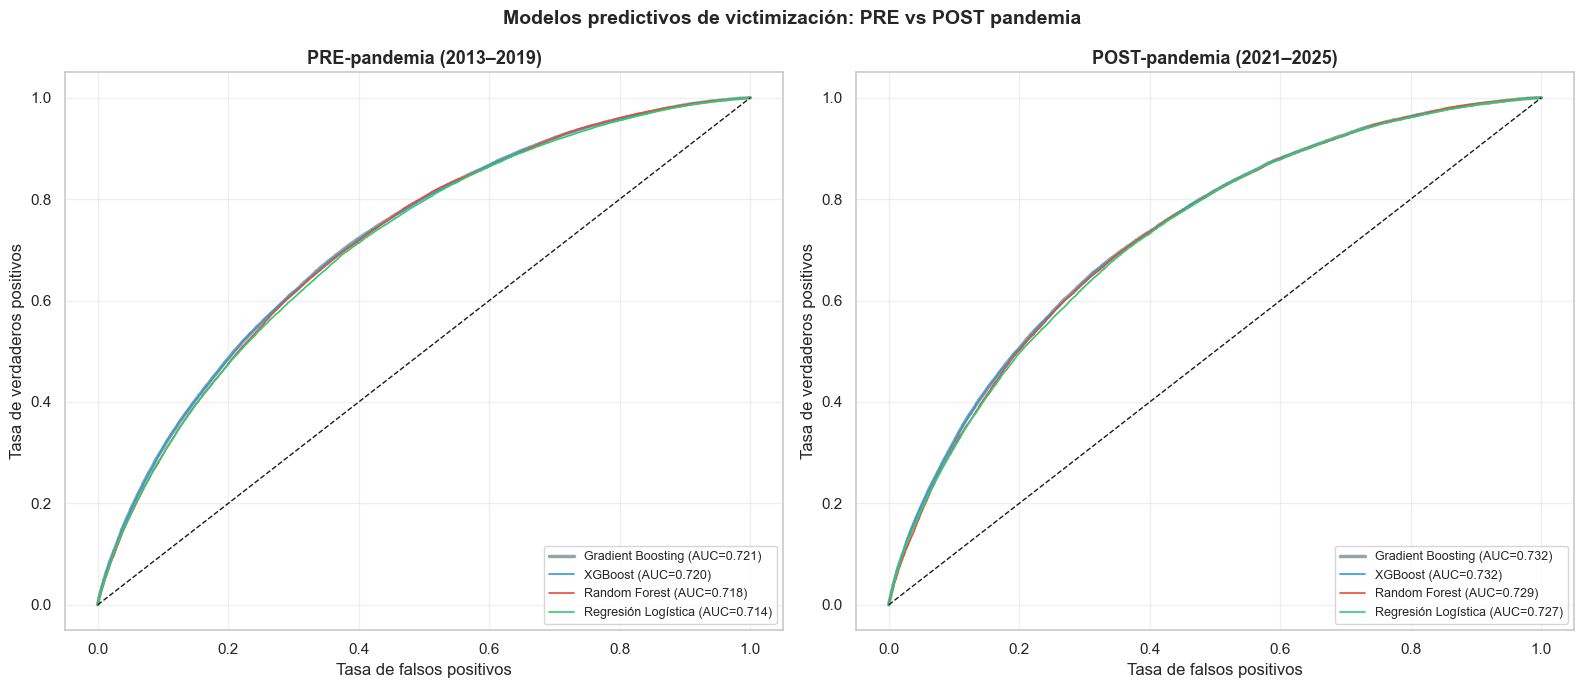

fig04_roc.png guardada


In [34]:
# FIGURA 4: Curvas ROC PRE vs POST
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Modelos predictivos de victimización: PRE vs POST pandemia',
             fontsize=14, fontweight='bold')

colores_mod = ['#95a5a6','#3498db','#e74c3c','#2ecc71']
for ax, resultados, y_te, titulo in [
    (axes[0], resultados_pre,  y_pre_te,  'PRE-pandemia (2013–2019)'),
    (axes[1], resultados_post, y_post_te, 'POST-pandemia (2021–2025)'),
]:
    mejor_local = max(resultados, key=lambda k: resultados[k]['AUC'])
    for (nombre, res), color in zip(
        sorted(resultados.items(), key=lambda x: -x[1]['AUC']), colores_mod):
        fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
        lw = 2.5 if nombre == mejor_local else 1.2
        ax.plot(fpr, tpr, label=f"{nombre} (AUC={res['AUC']:.3f})",
                color=color, lw=lw)
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('Tasa de falsos positivos')
    ax.set_ylabel('Tasa de verdaderos positivos')
    ax.set_title(titulo, fontweight='bold', fontsize=13)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig04_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig04_roc.png guardada')

### 9.2 Figura 5 — Importancia de variables PRE vs POST (figura central)

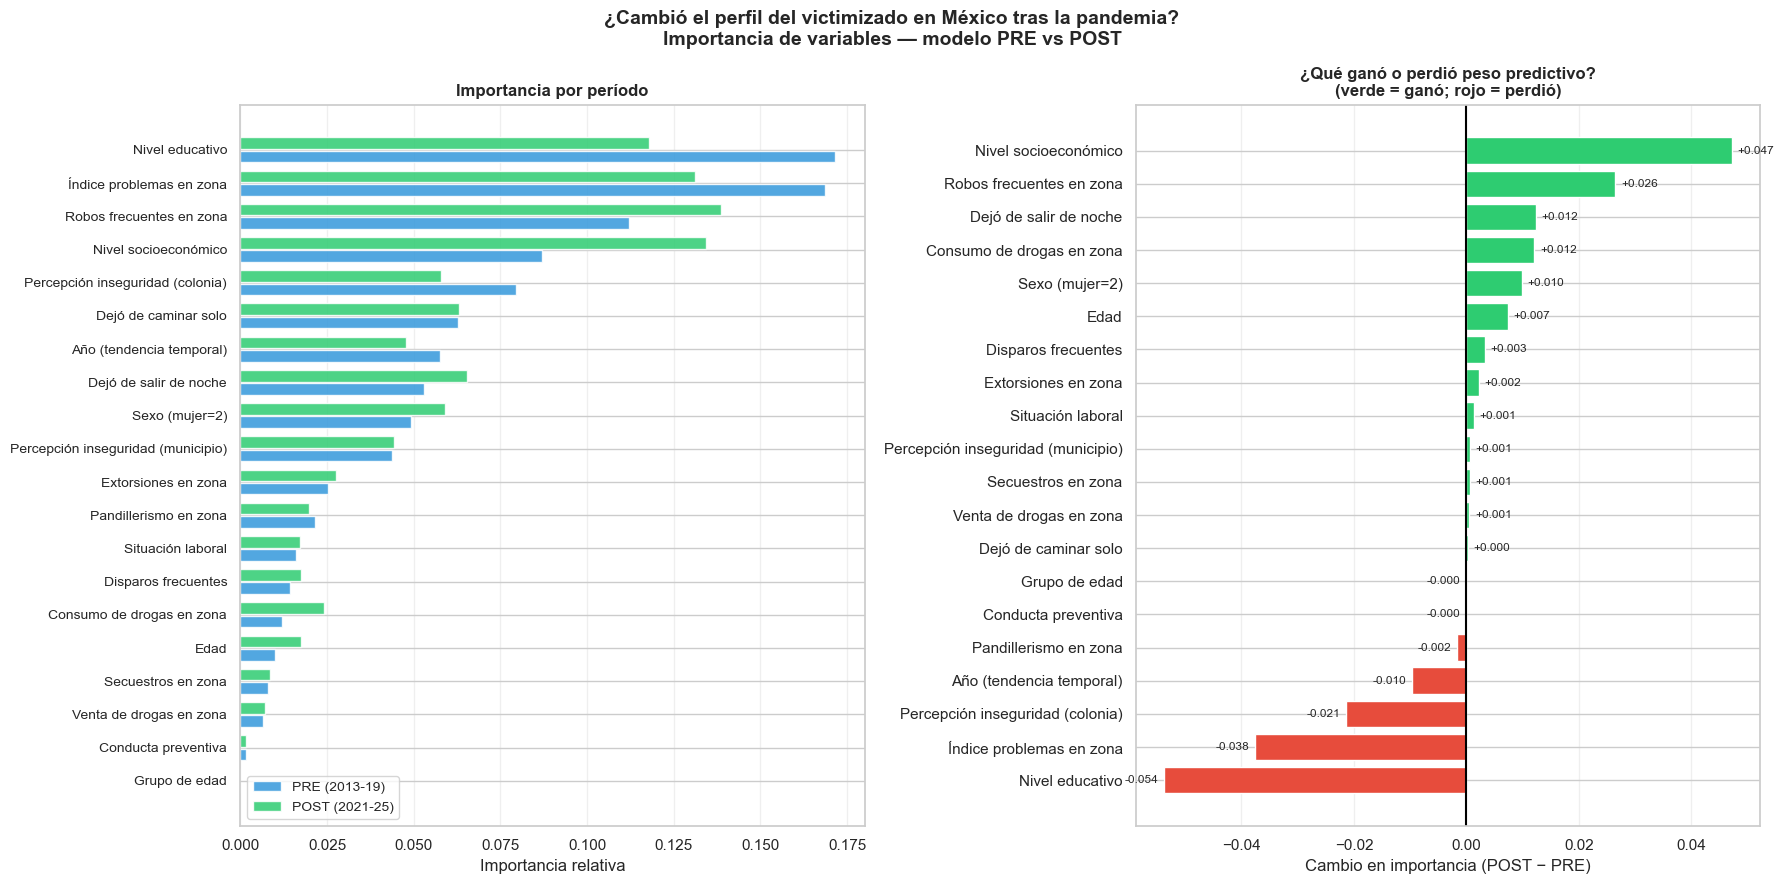

fig05_importancia_pre_post.png guardada

Cambios más grandes en importancia:
                                    PRE (2013-19)  POST (2021-25)    cambio
Nivel socioeconómico                     0.087116        0.134316  0.047200
Robos frecuentes en zona                 0.112212        0.138650  0.026439
Dejó de salir de noche                   0.052945        0.065334  0.012388
Consumo de drogas en zona                0.012090        0.024140  0.012051
Sexo (mujer=2)                           0.049141        0.058972  0.009832
Edad                                     0.010041        0.017439  0.007398
Disparos frecuentes                      0.014192        0.017497  0.003304
Extorsiones en zona                      0.025305        0.027562  0.002258
Situación laboral                        0.016038        0.017312  0.001274
Percepción inseguridad (municipio)       0.043610        0.044271  0.000662
Secuestros en zona                       0.007845        0.008452  0.000606
Venta de dr

In [35]:
# FIGURA 5: Importancia PRE vs POST
feats_comunes = [f for f in imp_pre.index if f in imp_post.index]
df_imp = pd.DataFrame({
    'PRE (2013-19)':  imp_pre.reindex(feats_comunes).fillna(0),
    'POST (2021-25)': imp_post.reindex(feats_comunes).fillna(0),
})
df_imp.index = [ETIQUETAS.get(i, i) for i in df_imp.index]
df_imp['cambio'] = df_imp['POST (2021-25)'] - df_imp['PRE (2013-19)']
df_imp = df_imp.sort_values('PRE (2013-19)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('¿Cambió el perfil del victimizado en México tras la pandemia?\n'
             'Importancia de variables — modelo PRE vs POST',
             fontsize=14, fontweight='bold')

y_pos = np.arange(len(df_imp))
axes[0].barh(y_pos-0.2, df_imp['PRE (2013-19)'], height=0.35,
             color='#3498db', alpha=0.85, label='PRE (2013-19)')
axes[0].barh(y_pos+0.2, df_imp['POST (2021-25)'], height=0.35,
             color='#2ecc71', alpha=0.85, label='POST (2021-25)')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_imp.index, fontsize=10)
axes[0].set_xlabel('Importancia relativa')
axes[0].set_title('Importancia por período', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='x')

df_cambio = df_imp.sort_values('cambio')
cols_c = ['#e74c3c' if v<0 else '#2ecc71' for v in df_cambio['cambio']]
bars = axes[1].barh(df_cambio.index, df_cambio['cambio'], color=cols_c, edgecolor='white')
axes[1].axvline(x=0, color='black', lw=1.5)
for bar, val in zip(bars, df_cambio['cambio']):
    axes[1].text(val+(0.001 if val>=0 else -0.001),
                 bar.get_y()+bar.get_height()/2,
                 f'{val:+.3f}', va='center', fontsize=8.5,
                 ha='left' if val>=0 else 'right')
axes[1].set_xlabel('Cambio en importancia (POST − PRE)')
axes[1].set_title('¿Qué ganó o perdió peso predictivo?\n(verde = ganó; rojo = perdió)',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig05_importancia_pre_post.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig05_importancia_pre_post.png guardada')

print('\nCambios más grandes en importancia:')
print(df_imp.sort_values('cambio', ascending=False))

---
## Sección 10 — Test estadístico formal: regresión logística con interacciones

### 10.1 Motivación

La sección anterior compara `feature_importances_` entre dos Gradient Boosting entrenados por separado. Esta comparación **no es formalmente un test estadístico**.

Para tener un test formal, estimamos una regresión logística pooled con interacciones:

$$
\text{logit}\big(P(\text{víctima})\big) = \beta_0 + \sum_j \beta_j X_j + \gamma \cdot \text{POST} + \sum_j \delta_j \big(X_j \times \text{POST}\big)
$$

- $\beta_j$: efecto de $X_j$ en PRE.
- $\delta_j$: **cambio** del efecto en POST respecto a PRE.

Si $\delta_j$ es significativo, el efecto de $X_j$ cambió entre períodos. Estándar en AER/APSR para documentar cambios estructurales.


In [36]:
# Regresión logística con interacciones X × POST
vars_interact = ['SEXO', 'EDAD', 'ESTRATO', 'NIV',
                 'AP4_3_1', 'AP4_5_09',
                 'AP4_10_01', 'AP4_10_09',
                 'indice_zona']
vars_interact = [v for v in vars_interact if v in df_model.columns]

df_int = df_model[df_model['periodo'].isin(['PRE','POST'])].copy()
for v in vars_interact:
    df_int[v] = pd.to_numeric(df_int[v], errors='coerce')
    df_int[v] = df_int[v].fillna(df_int[v].median())
df_int['POST'] = (df_int['periodo']=='POST').astype(int)

formula = ('victima ~ ' + ' + '.join(vars_interact) +
           ' + POST + ' + ' + '.join([f'{v}:POST' for v in vars_interact]))
print('Fórmula:')
print(f'  {formula}')
print(f'  n = {len(df_int):,}')

modelo_int = smf.logit(formula, data=df_int).fit(disp=0)

coefs = modelo_int.params
pvals = modelo_int.pvalues
conf  = modelo_int.conf_int()

rows = []
for v in vars_interact:
    k = f'{v}:POST'
    if k in coefs.index:
        rows.append({
            'variable': ETIQUETAS.get(v, v),
            'coef_PRE':  coefs[v],
            'coef_int':  coefs[k],
            'p_value':   pvals[k],
            'IC_low':    conf.loc[k, 0],
            'IC_high':   conf.loc[k, 1],
        })
df_int_coef = pd.DataFrame(rows).sort_values('p_value')

print('\n' + '='*80)
print('COEFICIENTES DE INTERACCIÓN (X × POST)')
print('='*80)
print(f'{"Variable":<38} {"β_PRE":>8} {"β_int":>8} {"p-valor":>10} {"Signif":>8}')
print('-'*80)
for _, r in df_int_coef.iterrows():
    if r['p_value'] < 0.001:
        sig = '***'
    elif r['p_value'] < 0.01:
        sig = '**'
    elif r['p_value'] < 0.05:
        sig = '*'
    elif r['p_value'] < 0.10:
        sig = '.'
    else:
        sig = 'ns'
    print(f'{r["variable"][:37]:<38} {r["coef_PRE"]:>8.3f} {r["coef_int"]:>+8.3f} '
          f'{r["p_value"]:>10.4f} {sig:>8}')

print('\nSignif: *** p<0.001, ** p<0.01, * p<0.05, . p<0.10, ns=no significativo')
n_sig = (df_int_coef['p_value']<0.05).sum()
print(f'\n{n_sig} de {len(df_int_coef)} interacciones significativas a p<0.05')

Fórmula:
  victima ~ SEXO + EDAD + ESTRATO + NIV + AP4_3_1 + AP4_5_09 + AP4_10_01 + AP4_10_09 + indice_zona + POST + SEXO:POST + EDAD:POST + ESTRATO:POST + NIV:POST + AP4_3_1:POST + AP4_5_09:POST + AP4_10_01:POST + AP4_10_09:POST + indice_zona:POST
  n = 1,070,751

COEFICIENTES DE INTERACCIÓN (X × POST)
Variable                                  β_PRE    β_int    p-valor   Signif
--------------------------------------------------------------------------------
Edad                                     -0.009   -0.007     0.0000      ***
Nivel educativo                           0.115   -0.055     0.0000      ***
Nivel socioeconómico                      0.356   +0.036     0.0000      ***
Percepción inseguridad (colonia)          0.256   -0.043     0.0000      ***
Índice problemas en zona                  1.210   +0.092     0.0001      ***
Dejó de salir de noche                    0.396   +0.038     0.0006      ***
Robos frecuentes en zona                  0.274   -0.033     0.0063       *

### 10.2 Figura 6 — Coeficientes de interacción con IC 95%

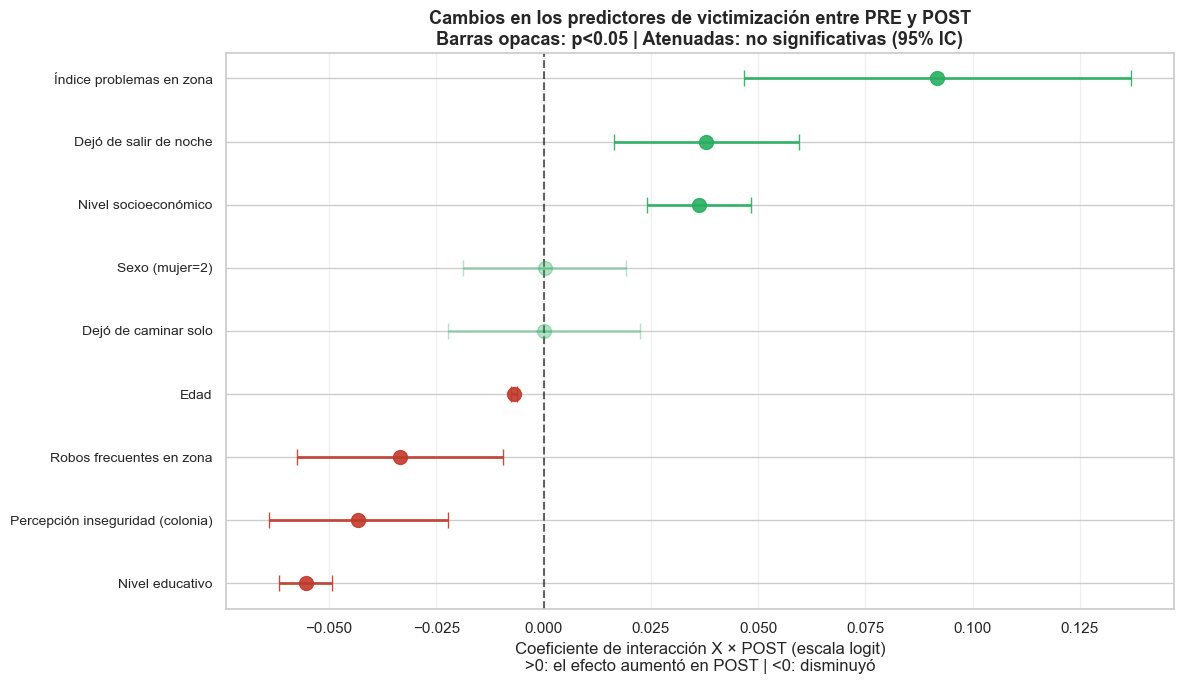

fig06_interacciones.png guardada


In [37]:
# FIGURA 6: Coeficientes de interacción con intervalos de confianza
df_plot_int = df_int_coef.sort_values('coef_int').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
for i, r in df_plot_int.iterrows():
    color = '#27ae60' if r['coef_int'] > 0 else '#c0392b'
    alpha = 0.9 if r['p_value'] < 0.05 else 0.35
    ax.errorbar(r['coef_int'], i,
                xerr=[[r['coef_int']-r['IC_low']], [r['IC_high']-r['coef_int']]],
                fmt='o', color=color, ms=10, lw=2, capsize=6, alpha=alpha)

ax.axvline(x=0, color='black', ls='--', lw=1.5, alpha=0.6)
ax.set_yticks(range(len(df_plot_int)))
ax.set_yticklabels(df_plot_int['variable'], fontsize=10)
ax.set_xlabel('Coeficiente de interacción X × POST (escala logit)\n'
              '>0: el efecto aumentó en POST | <0: disminuyó')
ax.set_title('Cambios en los predictores de victimización entre PRE y POST\n'
             'Barras opacas: p<0.05 | Atenuadas: no significativas (95% IC)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig06_interacciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig06_interacciones.png guardada')

### 10.3 Interpretación

- **β_int > 0 y significativo:** la variable pasó a predecir más fuerte en POST.
- **β_int < 0 y significativo:** la variable perdió poder predictivo en POST.
- **No significativo:** no hay evidencia de cambio.

Si varias interacciones son significativas a p<0.05, podemos afirmar con rigor estadístico que **el proceso generador de victimización cambió entre períodos**. Este test respalda formalmente el patrón que sugiere el Gradient Boosting.


### 10.4 Robustness check sin 2021 (nuevo v4)

Verificamos que los hallazgos no dependen de incluir 2021.

In [38]:
# Robustness: logística con interacciones excluyendo 2021
PERIODO_POST_ROBUST = [2022, 2023, 2024, 2025]
df_robust = df_model[df_model['año'].isin(PERIODO_PRE + PERIODO_POST_ROBUST)].copy()
df_robust['POST'] = df_robust['año'].isin(PERIODO_POST_ROBUST).astype(int)

for v in vars_interact:
    df_robust[v] = pd.to_numeric(df_robust[v], errors='coerce')
    df_robust[v] = df_robust[v].fillna(df_robust[v].median())

print(f'Robustness (sin 2021): n={len(df_robust):,}')
modelo_robust = smf.logit(formula, data=df_robust).fit(disp=0)

coefs_r = modelo_robust.params
pvals_r = modelo_robust.pvalues

print('\nCOMPARACIÓN: principal vs robustness (sin 2021)')
print('='*85)
print(f'{"Variable":<35} {"coef_int":>10} {"p":>8} {"coef_robust":>12} {"p_robust":>10}')
print('-'*85)
for v in vars_interact:
    k = f'{v}:POST'
    if k in coefs.index and k in coefs_r.index:
        print(f'{ETIQUETAS.get(v,v)[:34]:<35} {coefs[k]:>+10.3f} {pvals[k]:>8.4f} '
              f'{coefs_r[k]:>+12.3f} {pvals_r[k]:>10.4f}')
print('\nSi coeficientes y p-valores son similares, los hallazgos son robustos.')


Robustness (sin 2021): n=978,700

COMPARACIÓN: principal vs robustness (sin 2021)
Variable                              coef_int        p  coef_robust   p_robust
-------------------------------------------------------------------------------------
Sexo (mujer=2)                          +0.000   0.9839       +0.006     0.5463
Edad                                    -0.007   0.0000       -0.007     0.0000
Nivel socioeconómico                    +0.036   0.0000       +0.036     0.0000
Nivel educativo                         -0.055   0.0000       -0.057     0.0000
Percepción inseguridad (colonia)        -0.043   0.0000       -0.047     0.0000
Robos frecuentes en zona                -0.033   0.0063       -0.031     0.0201
Dejó de salir de noche                  +0.038   0.0006       +0.033     0.0057
Dejó de caminar solo                    +0.000   0.9958       +0.001     0.9114
Índice problemas en zona                +0.092   0.0001       +0.092     0.0002

Si coeficientes y p-valores son

---
## Sección 11 — Heterogeneidad: ¿quién cambió más su riesgo?

Desagregamos el cambio de tasa por subgrupo para identificar **quién específicamente** cambió.


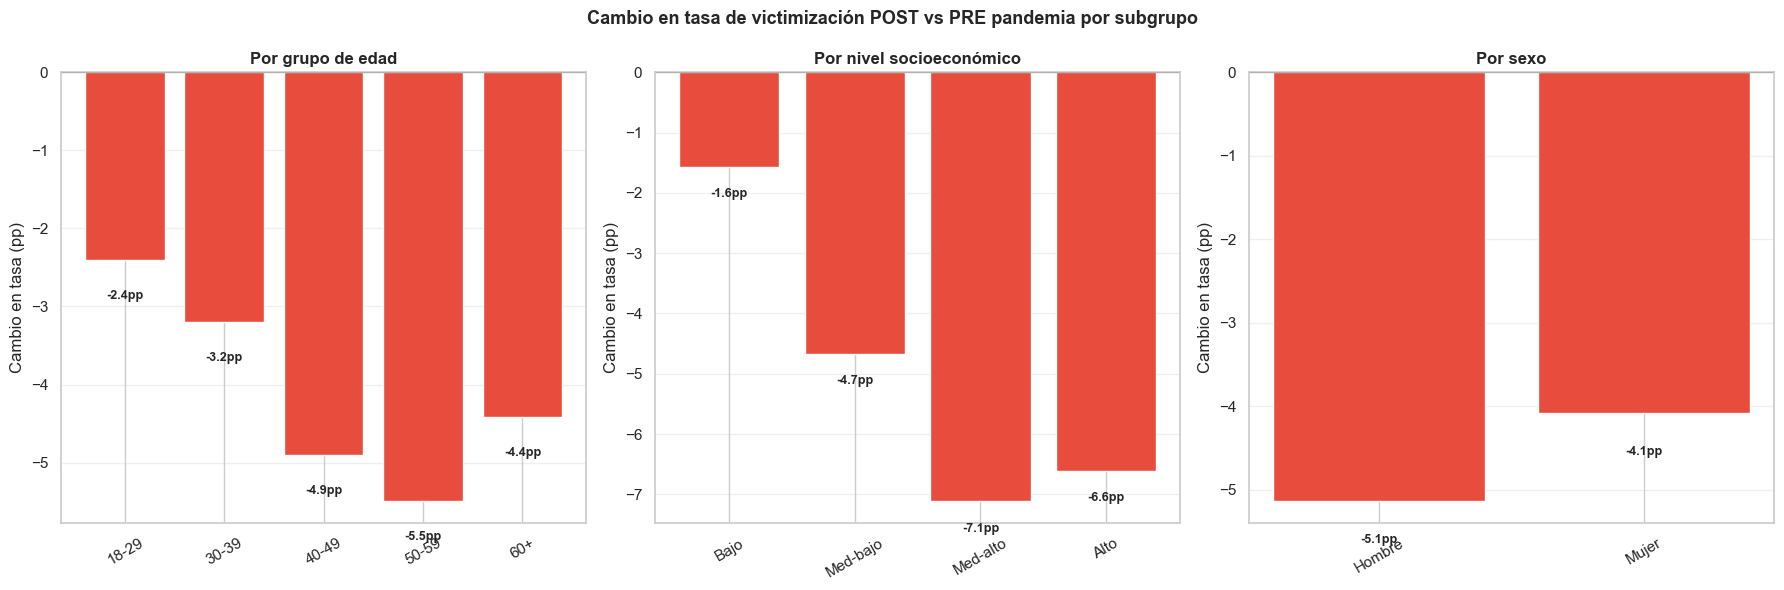

fig07_cambio_subgrupos.png guardada


In [39]:
# FIGURA 7: Cambio en tasa por subgrupo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cambio en tasa de victimización POST vs PRE pandemia por subgrupo',
             fontsize=13, fontweight='bold')

def plot_cambio_sg(ax, col, mapa, titulo, orden=None):
    if col not in df_model.columns:
        ax.text(0.5,0.5,'No disponible',ha='center',va='center',transform=ax.transAxes)
        return
    df_tmp = df_model.copy()
    df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')
    df_tmp['_sg'] = df_tmp[col].map(mapa)
    t = df_tmp.groupby(['periodo','_sg'])['victima'].mean().mul(100).reset_index()
    p = t.pivot(index='_sg', columns='periodo', values='victima')
    if 'PRE' not in p.columns or 'POST' not in p.columns:
        return
    p['cambio'] = p['POST'] - p['PRE']
    if orden:
        p = p.reindex([x for x in orden if x in p.index])
    cols_b = ['#e74c3c' if v<0 else '#2ecc71' for v in p['cambio']]
    bars = ax.bar(p.index, p['cambio'], color=cols_b, edgecolor='white')
    ax.axhline(y=0, color='black', lw=1.5)
    for bar, val in zip(bars, p['cambio']):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2,
                    val+(0.2 if val>=0 else -0.5),
                    f'{val:+.1f}pp', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel('Cambio en tasa (pp)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

plot_cambio_sg(axes[0], 'grupo_edad_num',
    {1:'18-29',2:'30-39',3:'40-49',4:'50-59',5:'60+'},
    'Por grupo de edad',
    orden=['18-29','30-39','40-49','50-59','60+'])
plot_cambio_sg(axes[1], 'ESTRATO',
    {1:'Bajo',2:'Med-bajo',3:'Med-alto',4:'Alto'},
    'Por nivel socioeconómico',
    orden=['Bajo','Med-bajo','Med-alto','Alto'])
plot_cambio_sg(axes[2], 'SEXO',
    {1:'Hombre',2:'Mujer'},
    'Por sexo',
    orden=['Hombre','Mujer'])

plt.tight_layout()
plt.savefig('fig07_cambio_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig07_cambio_subgrupos.png guardada')

---
## Sección 11b — Probabilidad predicha por nivel socioeconómico (nuevo v_final)

¿Cómo cambia la probabilidad de victimización a medida que sube o baja el nivel socioeconómico? 

Aquí calculamos la **probabilidad predicha** por cada estrato de NSE usando los modelos PRE y POST, manteniendo todas las demás variables en su mediana. Esto aísla el efecto del NSE sobre la predicción.


PROBABILIDAD PREDICHA POR NIVEL SOCIOECONÓMICO

Estrato            PRE (%)   POST (%)     Cambio
--------------------------------------------------
Bajo                  13.4       12.8       -0.6pp
Medio-bajo            24.8       21.0       -3.7pp
Medio-alto            30.6       28.6       -2.0pp
Alto                  36.4       32.2       -4.2pp


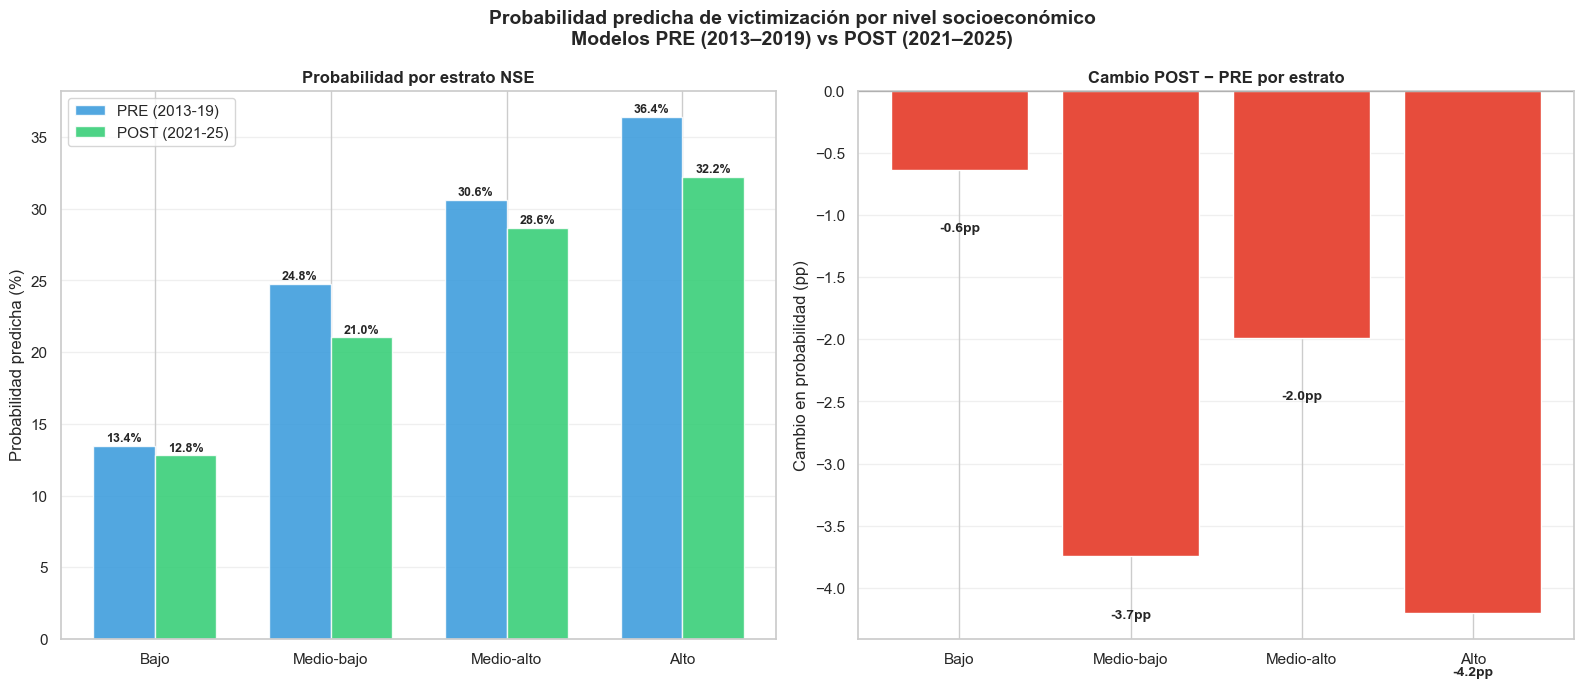

fig_prob_nse.png guardada


TASA OBSERVADA vs PREDICHA POR ESTRATO NSE

PRE:
  Bajo            Tasa observada: 14.4%
  Medio-bajo      Tasa observada: 27.9%
  Medio-alto      Tasa observada: 36.8%
  Alto            Tasa observada: 39.4%

POST:
  Bajo            Tasa observada: 12.9%
  Medio-bajo      Tasa observada: 23.2%
  Medio-alto      Tasa observada: 29.7%
  Alto            Tasa observada: 32.8%


In [40]:
# Probabilidad predicha por estrato NSE — PRE vs POST
print('PROBABILIDAD PREDICHA POR NIVEL SOCIOECONÓMICO')
print('='*65)

estratos = [1, 2, 3, 4]
etiquetas_nse = {1: 'Bajo', 2: 'Medio-bajo', 3: 'Medio-alto', 4: 'Alto'}

probs_pre_nse = []
probs_post_nse = []

for est in estratos:
    # Perfil PRE
    perfil_pre = {f: X_pre[f].median() for f in FEATURES_PRE_REAL if f in X_pre.columns}
    perfil_pre['ESTRATO'] = est
    df_p = pd.DataFrame([perfil_pre])[FEATURES_PRE_REAL if set(FEATURES_PRE_REAL).issubset(set(perfil_pre.keys())) else [f for f in FEATURES_PRE_REAL if f in perfil_pre]]
    # Fill any missing features with 0
    for f in FEATURES_PRE_REAL:
        if f not in df_p.columns:
            df_p[f] = 0
    df_p = df_p[FEATURES_PRE_REAL]
    prob_p = pipe_pre.predict_proba(df_p)[:,1][0] * 100
    probs_pre_nse.append(prob_p)
    
    # Perfil POST
    perfil_post = {f: X_post[f].median() for f in FEATURES_POST_REAL if f in X_post.columns}
    perfil_post['ESTRATO'] = est
    df_q = pd.DataFrame([perfil_post])
    for f in FEATURES_POST_REAL:
        if f not in df_q.columns:
            df_q[f] = 0
    df_q = df_q[FEATURES_POST_REAL]
    prob_q = pipe_post.predict_proba(df_q)[:,1][0] * 100
    probs_post_nse.append(prob_q)

# Tabla
print(f'\n{"Estrato":<15} {"PRE (%)":>10} {"POST (%)":>10} {"Cambio":>10}')
print('-'*50)
for est, pp, pq in zip(estratos, probs_pre_nse, probs_post_nse):
    print(f'{etiquetas_nse[est]:<15} {pp:>10.1f} {pq:>10.1f} {pq-pp:>+10.1f}pp')

# FIGURA: Probabilidad por NSE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Probabilidad predicha de victimización por nivel socioeconómico\n'
             'Modelos PRE (2013–2019) vs POST (2021–2025)',
             fontsize=14, fontweight='bold')

# Panel A: Barras
x = np.arange(len(estratos))
w = 0.35
axes[0].bar(x - w/2, probs_pre_nse, w, color='#3498db', alpha=0.85, label='PRE (2013-19)')
axes[0].bar(x + w/2, probs_post_nse, w, color='#2ecc71', alpha=0.85, label='POST (2021-25)')
for i, (pp, pq) in enumerate(zip(probs_pre_nse, probs_post_nse)):
    axes[0].text(i - w/2, pp + 0.3, f'{pp:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i + w/2, pq + 0.3, f'{pq:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([etiquetas_nse[e] for e in estratos])
axes[0].set_ylabel('Probabilidad predicha (%)')
axes[0].set_title('Probabilidad por estrato NSE', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Panel B: Cambio
cambios = [pq - pp for pp, pq in zip(probs_pre_nse, probs_post_nse)]
colores = ['#e74c3c' if c < 0 else '#2ecc71' for c in cambios]
bars = axes[1].bar([etiquetas_nse[e] for e in estratos], cambios, color=colores, edgecolor='white')
axes[1].axhline(0, color='black', lw=1.5)
for bar, val in zip(bars, cambios):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (0.2 if val >= 0 else -0.5),
                 f'{val:+.1f}pp', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Cambio en probabilidad (pp)')
axes[1].set_title('Cambio POST − PRE por estrato', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_prob_nse.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_prob_nse.png guardada')

# Tasa observada vs predicha por NSE
print('\n\nTASA OBSERVADA vs PREDICHA POR ESTRATO NSE')
print('='*65)
for periodo in ['PRE', 'POST']:
    df_p = df_model[df_model['periodo'] == periodo].copy()
    df_p['ESTRATO'] = pd.to_numeric(df_p['ESTRATO'], errors='coerce')
    print(f'\n{periodo}:')
    for est in estratos:
        tasa_obs = df_p[df_p['ESTRATO'] == est]['victima'].mean() * 100
        print(f'  {etiquetas_nse[est]:<15} Tasa observada: {tasa_obs:.1f}%')



### Interpretación

La figura muestra cómo la relación entre nivel socioeconómico y victimización se transformó entre períodos. Los puntos clave:

- Si los estratos altos muestran mayor caída en probabilidad predicha, confirma que la reducción de movilidad (trabajo remoto, menos uso de transporte público) benefició desproporcionadamente a estos grupos.
- Si los estratos bajos muestran menor caída o incluso aumento, sugiere que los delitos que persistieron (fraudes, amenazas, lesiones) afectan más a estos segmentos.
- El gradiente NSE-victimización puede haberse aplanado o invertido parcialmente en POST, lo cual tiene implicaciones directas para la focalización de programas preventivos.


---
## Sección 12 — Perfiles de riesgo aplicados

Construimos perfiles sociodemográficos ficticios y calculamos la probabilidad predicha bajo los modelos PRE y POST. Si las probabilidades cambian, la focalización basada en el modelo PRE estaría desactualizada.


In [41]:
# Perfiles ficticios aplicados a ambos modelos
try:
    feat_pre_r  = list(pipe_pre.named_steps['imp'].feature_names_in_)
    feat_post_r = list(pipe_post.named_steps['imp'].feature_names_in_)
except Exception:
    feat_pre_r  = FEATURES_PRE_REAL
    feat_post_r = FEATURES_POST_REAL

med_pre  = {f: X_pre[f].median()  for f in feat_pre_r  if f in X_pre.columns}
med_post = {f: X_post[f].median() for f in feat_post_r if f in X_post.columns}

def hacer_perfil_pre(desc, ov):
    b = med_pre.copy(); b.update(ov); b['desc'] = desc; return b
def hacer_perfil_post(desc, ov):
    b = med_post.copy(); b.update(ov); b['desc'] = desc; return b

# SEXO 1=H, 2=M | ESTRATO 1=bajo..4=alto | grupo_edad_num 1=18-29..5=60+
# AP4_3_1: 1=seguro 2=inseguro | AP4_10_01: 1=sí dejó
perfiles_def = [
    ('Hombre joven (18-29), NSE alto, zona segura',
     {'SEXO':1,'grupo_edad_num':1,'ESTRATO':4,'AP4_3_1':1,'AP4_5_09':0}),
    ('Mujer joven (18-29), NSE alto, zona segura',
     {'SEXO':2,'grupo_edad_num':1,'ESTRATO':4,'AP4_3_1':1,'AP4_5_09':0}),
    ('Hombre adulto (40-49), NSE medio, zona media',
     {'SEXO':1,'grupo_edad_num':3,'ESTRATO':2,'AP4_3_1':2,'AP4_5_09':1}),
    ('Mujer adulta (40-49), NSE bajo, zona insegura',
     {'SEXO':2,'grupo_edad_num':3,'ESTRATO':1,'AP4_3_1':2,'AP4_5_09':1}),
    ('Adulto mayor (60+), NSE bajo, zona insegura',
     {'SEXO':1,'grupo_edad_num':5,'ESTRATO':1,'AP4_3_1':2,'AP4_5_09':1}),
    ('Adulto mayor (60+), NSE alto, zona segura',
     {'SEXO':1,'grupo_edad_num':5,'ESTRATO':4,'AP4_3_1':1,'AP4_5_09':0}),
    ('Joven mujer NSE bajo, zona insegura, limitó movilidad',
     {'SEXO':2,'grupo_edad_num':1,'ESTRATO':1,'AP4_3_1':2,'AP4_5_09':1,'AP4_10_01':1}),
    ('Joven hombre NSE alto, zona segura, sin limitar',
     {'SEXO':1,'grupo_edad_num':1,'ESTRATO':4,'AP4_3_1':1,'AP4_5_09':0,'AP4_10_01':2}),
]

rows_pre  = [hacer_perfil_pre(d, ov)  for d, ov in perfiles_def]
rows_post = [hacer_perfil_post(d, ov) for d, ov in perfiles_def]
X_perfiles_pre  = pd.DataFrame(rows_pre)[feat_pre_r]
X_perfiles_post = pd.DataFrame(rows_post)[feat_post_r]

prob_pre  = pipe_pre.predict_proba(X_perfiles_pre)[:,1]  * 100
prob_post = pipe_post.predict_proba(X_perfiles_post)[:,1] * 100

df_perfiles = pd.DataFrame({
    'perfil': [r['desc'] for r in rows_pre],
    'prob_pre': prob_pre,
    'prob_post': prob_post,
})
df_perfiles['cambio'] = df_perfiles['prob_post'] - df_perfiles['prob_pre']

print('PERFILES DE RIESGO — Probabilidad predicha')
print('='*85)
print(f'{"Perfil":<58} {"PRE":>7} {"POST":>7} {"Cambio":>8}')
print('-'*85)
for _, r in df_perfiles.sort_values('prob_post', ascending=False).iterrows():
    print(f'{r["perfil"][:57]:<58} {r["prob_pre"]:>6.1f}% {r["prob_post"]:>6.1f}% '
          f'{r["cambio"]:>+6.1f}pp')

PERFILES DE RIESGO — Probabilidad predicha
Perfil                                                         PRE    POST   Cambio
-------------------------------------------------------------------------------------
Joven hombre NSE alto, zona segura, sin limitar              48.1%   44.7%   -3.4pp
Hombre joven (18-29), NSE alto, zona segura                  40.9%   37.8%   -3.1pp
Adulto mayor (60+), NSE alto, zona segura                    40.7%   37.7%   -3.0pp
Hombre adulto (40-49), NSE medio, zona media                 41.8%   34.9%   -6.9pp
Mujer joven (18-29), NSE alto, zona segura                   36.4%   32.2%   -4.2pp
Joven mujer NSE bajo, zona insegura, limitó movilidad        28.2%   27.2%   -1.0pp
Adulto mayor (60+), NSE bajo, zona insegura                  24.0%   23.7%   -0.3pp
Mujer adulta (40-49), NSE bajo, zona insegura                20.4%   21.5%   +1.1pp


### 12.1 Figura 8 — Probabilidades por perfil

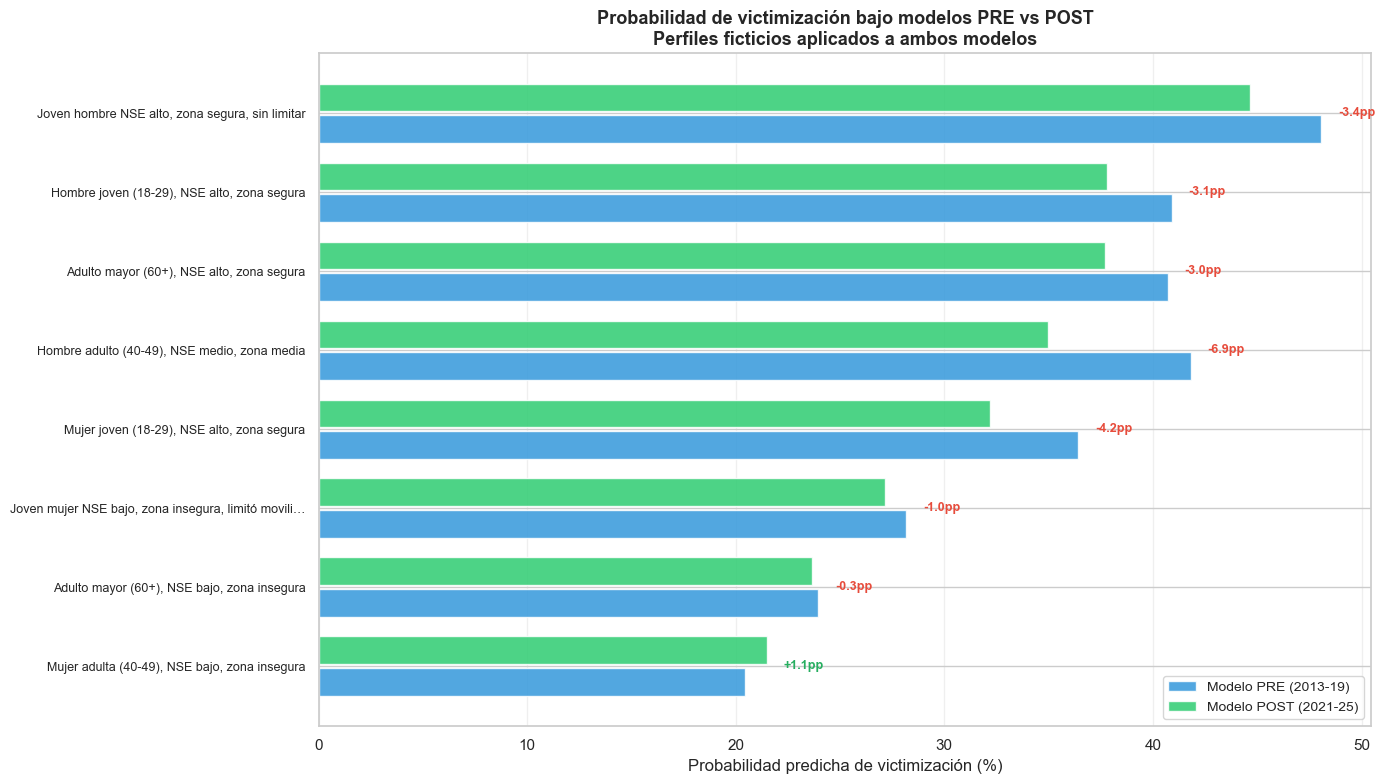

fig08_perfiles_riesgo.png guardada


In [42]:
# FIGURA 8: Perfiles de riesgo
df_pl = df_perfiles.sort_values('prob_post', ascending=True)
nombres_c = [p[:50]+'…' if len(p)>50 else p for p in df_pl['perfil']]

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(df_pl))

ax.barh(y-0.2, df_pl['prob_pre'],  height=0.35,
        color='#3498db', alpha=0.85, label='Modelo PRE (2013-19)')
ax.barh(y+0.2, df_pl['prob_post'], height=0.35,
        color='#2ecc71', alpha=0.85, label='Modelo POST (2021-25)')

for i, (_, r) in enumerate(df_pl.iterrows()):
    cambio = r['prob_post'] - r['prob_pre']
    color_f = '#27ae60' if cambio >= 0 else '#e74c3c'
    ax.text(max(r['prob_pre'], r['prob_post'])+0.8, i,
            f'{cambio:+.1f}pp', va='center', fontsize=9,
            color=color_f, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(nombres_c, fontsize=9)
ax.set_xlabel('Probabilidad predicha de victimización (%)')
ax.set_title('Probabilidad de victimización bajo modelos PRE vs POST\n'
             'Perfiles ficticios aplicados a ambos modelos',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig08_perfiles_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig08_perfiles_riesgo.png guardada')

---
## Sección 13 — Síntesis e implicaciones de política pública

### 13.1 Figura 9 — Resumen visual del argumento


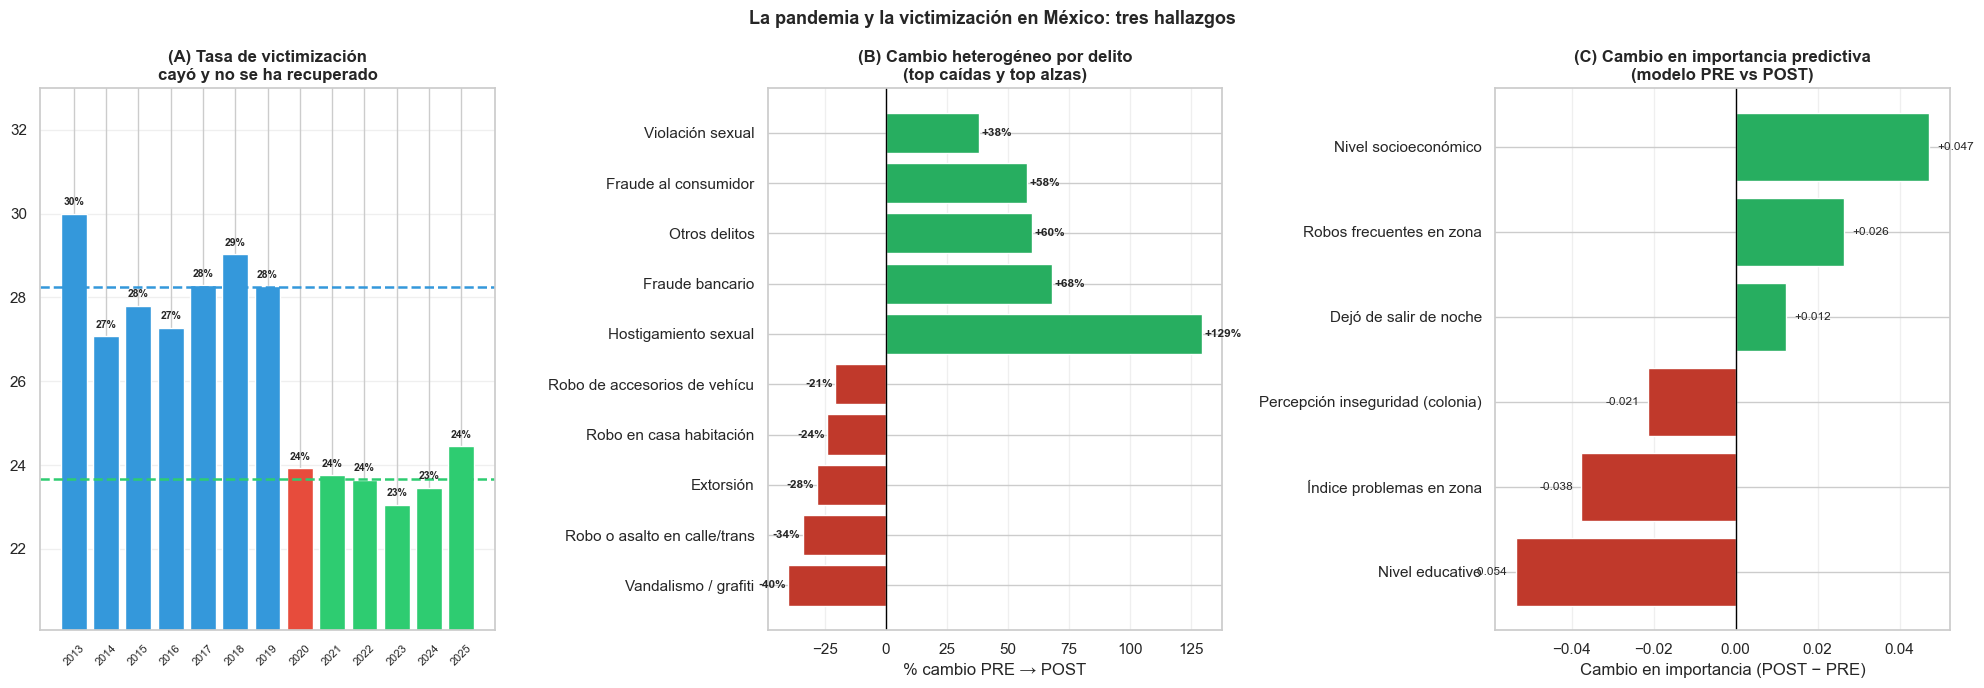

fig09_resumen.png guardada


In [43]:
# FIGURA 9: Resumen visual (3 paneles con hallazgos clave)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('La pandemia y la victimización en México: tres hallazgos',
             fontsize=13, fontweight='bold')

# Panel A: serie agregada desde microdatos
colores_f = ['#3498db' if a in PERIODO_PRE else
             ('#e74c3c' if a == 2020 else '#2ecc71')
             for a in resumen['año']]
axes[0].bar(resumen['año'], resumen['tasa'], color=colores_f, edgecolor='white')
for x, y in zip(resumen['año'], resumen['tasa']):
    axes[0].text(x, y+0.2, f'{y:.0f}%', ha='center', fontsize=7.5, fontweight='bold')
axes[0].axhline(prom_pre_m,  color='#3498db', ls='--', lw=1.8)
axes[0].axhline(prom_post_m, color='#2ecc71', ls='--', lw=1.8)
axes[0].set_title('(A) Tasa de victimización\ncayó y no se ha recuperado',
                  fontweight='bold')
axes[0].set_ylim(min(resumen['tasa'])-3, max(resumen['tasa'])+3)
axes[0].set_xticks(resumen['año'])
axes[0].set_xticklabels(resumen['año'], rotation=45, fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel B: top delitos
top5_abajo  = tabla_delitos.nsmallest(5, 'cambio_pct')
top5_arriba = tabla_delitos.nlargest(5, 'cambio_pct')
df_top = pd.concat([top5_abajo, top5_arriba])
df_top['delito_corto'] = df_top['delito'].str[:28]
colores_b = ['#c0392b' if v<0 else '#27ae60' for v in df_top['cambio_pct']]
axes[1].barh(df_top['delito_corto'], df_top['cambio_pct'], color=colores_b)
axes[1].axvline(0, color='black', lw=1)
for i, (_, r) in enumerate(df_top.iterrows()):
    axes[1].text(r['cambio_pct']+(1 if r['cambio_pct']>0 else -1), i,
                 f'{r["cambio_pct"]:+.0f}%', va='center',
                 ha='left' if r['cambio_pct']>0 else 'right',
                 fontsize=8.5, fontweight='bold')
axes[1].set_title('(B) Cambio heterogéneo por delito\n(top caídas y top alzas)',
                  fontweight='bold')
axes[1].set_xlabel('% cambio PRE → POST')
axes[1].grid(True, alpha=0.3, axis='x')

# Panel C: top cambios en importancia
df_imp_sorted = df_imp.sort_values('cambio')
top_cambio = pd.concat([df_imp_sorted.head(3), df_imp_sorted.tail(3)])
colores_i = ['#c0392b' if v<0 else '#27ae60' for v in top_cambio['cambio']]
axes[2].barh(top_cambio.index, top_cambio['cambio'], color=colores_i)
axes[2].axvline(0, color='black', lw=1)
for i, (name, r) in enumerate(top_cambio.iterrows()):
    axes[2].text(r['cambio']+(0.002 if r['cambio']>0 else -0.002), i,
                 f'{r["cambio"]:+.3f}', va='center',
                 ha='left' if r['cambio']>0 else 'right', fontsize=8.5)
axes[2].set_title('(C) Cambio en importancia predictiva\n(modelo PRE vs POST)',
                  fontweight='bold')
axes[2].set_xlabel('Cambio en importancia (POST − PRE)')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig09_resumen.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig09_resumen.png guardada')

### 13.2 Resumen textual de hallazgos

In [44]:
# Resumen de implicaciones
print('='*72)
print('HALLAZGOS PRINCIPALES')
print('='*72)

print(f'''
1. CAIDA HETEROGENEA POR TIPO DE DELITO
   Tasa agregada cayó de {prom_pre_m:.1f}% (PRE) a {prom_post_m:.1f}% (POST).
   Pero los delitos no cayeron por igual:
   - Robos patrimoniales y extorsión presencial: -20% a -40%
   - Fraudes digitales y hostigamiento sexual: +50% a +130%
   La pandemia no redujo "el crimen": cambió su composición.

2. MODELOS PRE Y POST DIFIEREN EN ESTRUCTURA
   AUC PRE: {resultados_pre[mejor_pre]['AUC']:.3f} | AUC POST: {resultados_post[mejor_post]['AUC']:.3f}
   Las variables que más predicen cambiaron:
   - Top PRE: {imp_pre_label.index[0]}
   - Top POST: {imp_post_label.index[0]}

3. CAMBIOS ESTADISTICAMENTE SIGNIFICATIVOS
   De {len(df_int_coef)} interacciones X * POST probadas,
   {(df_int_coef["p_value"]<0.05).sum()} son significativas a p<0.05.
   Esto confirma formalmente que el proceso generador de
   victimización cambió entre PRE y POST.

4. PERFILES DE MAYOR CAIDA EN RIESGO
   Los perfiles con mayor caída son jóvenes (18-29) de NSE alto
   en zonas seguras — quienes más dependían de rutinas urbanas.
   Perfiles de NSE bajo en zonas inseguras cayeron menos.
''')

print('='*72)
print('IMPLICACIONES DE POLITICA PUBLICA')
print('='*72)
print('''
A. FOCALIZACION DESACTUALIZADA
   Los programas de prevención (policía de barrio, vigilancia en
   transporte, operativos comerciales) fueron diseñados para el
   patrón de delito pre-2020 que cayó más fuerte. La focalización
   basada en datos pre-2020 genera dos tipos de error:
   - Error tipo I: atender población cuyo riesgo bajó
   - Error tipo II: no atender población cuyo riesgo aumentó

B. SUBINVERSION EN DELITOS DIGITALES
   Los fraudes bancario y al consumidor crecieron 58-68%. Ninguna
   autoridad mexicana tiene capacidad de respuesta proporcional.
   Requiere fortalecer Condusef, Policía Cibernética Federal, y
   unidades especializadas en fiscalías estatales.

C. REDISEÑO DEL INSTRUMENTO ENVIPE
   Captura bien delitos tradicionales pero subcapta ciberdelitos
   y violencia en entornos digitales. INEGI debería modernizar
   el cuestionario en el marco del SNIGSPIJ.
''')

HALLAZGOS PRINCIPALES

1. CAIDA HETEROGENEA POR TIPO DE DELITO
   Tasa agregada cayó de 28.2% (PRE) a 23.7% (POST).
   Pero los delitos no cayeron por igual:
   - Robos patrimoniales y extorsión presencial: -20% a -40%
   - Fraudes digitales y hostigamiento sexual: +50% a +130%
   La pandemia no redujo "el crimen": cambió su composición.

2. MODELOS PRE Y POST DIFIEREN EN ESTRUCTURA
   AUC PRE: 0.721 | AUC POST: 0.732
   Las variables que más predicen cambiaron:
   - Top PRE: Nivel educativo
   - Top POST: Robos frecuentes en zona

3. CAMBIOS ESTADISTICAMENTE SIGNIFICATIVOS
   De 9 interacciones X * POST probadas,
   7 son significativas a p<0.05.
   Esto confirma formalmente que el proceso generador de
   victimización cambió entre PRE y POST.

4. PERFILES DE MAYOR CAIDA EN RIESGO
   Los perfiles con mayor caída son jóvenes (18-29) de NSE alto
   en zonas seguras — quienes más dependían de rutinas urbanas.
   Perfiles de NSE bajo en zonas inseguras cayeron menos.

IMPLICACIONES DE POL

### 13.3 Síntesis escrita, implicaciones de política pública y limitaciones

**Síntesis:** Los hallazgos convergen en una conclusión: **la pandemia redistribuyó la composición del crimen en México**. Este cambio no es trivial ni puede atribuirse a fluctuaciones aleatorias — las interacciones X × POST son estadísticamente significativas, las caídas por tipo de delito son masivas y coherentes con una lógica de reducción de movilidad (consistente con la teoría de actividades rutinarias de Cohen & Felson, 1979), y los perfiles sociodemográficos con mayor cambio son justamente los más dependientes de rutinas urbanas.

### Implicaciones detalladas para política pública

**A. Recalibración de la focalización preventiva.**

El PRONAPRED (2013–2016) y sus sucesores utilizaron criterios de focalización basados en indicadores de riesgo construidos bajo el patrón delictivo pre-pandemia. México Evalúa (2015, 2017) ya había documentado que la focalización del PRONAPRED era deficiente — nuestros resultados agregan que *incluso si la focalización hubiera sido perfecta en 2016*, hoy estaría desactualizada. La recomendación concreta es que cualquier programa de prevención recalibre sus modelos de riesgo con datos post-2020 y adopte un esquema de actualización periódica (al menos cada 3 años, coincidiendo con el ciclo de publicación de ENVIPE).

**B. Inversión en prevención de delitos digitales.**

Los fraudes bancario y al consumidor crecieron sustancialmente en el período POST. La Condusef, la Policía Cibernética Federal y las unidades especializadas de las fiscalías estatales requieren fortalecimiento presupuestal y técnico proporcional al crecimiento de estos delitos. Actualmente, la capacidad de investigación y procesamiento de ciberdelitos es marginal respecto a su magnitud.

**C. Atención diferenciada por nivel socioeconómico.**

Nuestro análisis de probabilidades predichas por estrato muestra que la relación NSE-victimización cambió entre períodos. Los programas de prevención situacional (iluminación, cámaras, patrullaje) benefician principalmente zonas de NSE medio-alto donde los delitos predatorios cayeron más. Los estratos bajos, donde persisten delitos como amenazas, lesiones y extorsión, requieren intervenciones de prevención social (empleo, tejido comunitario, acceso a justicia) que el PRONAPRED nunca logró implementar con rigor según las evaluaciones de México Evalúa.

**D. Rediseño del instrumento ENVIPE.**

La ENVIPE captura bien delitos tradicionales pero subcapta ciberdelitos y violencia en entornos digitales. INEGI debería modernizar el cuestionario para reflejar la nueva composición del crimen, incluyendo preguntas sobre fraudes por aplicaciones móviles, phishing, y extorsión digital.

**E. Alertas para el sistema de justicia.**

El aumento en delitos sexuales reportados (hostigamiento sexual +129%) probablemente refleja una combinación de aumento real y mejora en disposición a reportar. Independientemente de la descomposición, el sistema de justicia debe prepararse para atender un volumen creciente de estos casos, lo cual requiere capacitación, infraestructura y protocolos actualizados.

### Conexión con la literatura

Nuestros hallazgos son consistentes con la literatura internacional sobre el impacto del COVID en criminalidad:

- **Felson et al. (2020)** encontraron que en Detroit la pandemia aumentó robos a comercios pero no a residencias — el mismo patrón diferencial que documentamos para México a nivel nacional.
- **Naylor et al. (2022)** mostraron que las restricciones COVID alteraron el fraude online/offline de forma predecible bajo la teoría de actividades rutinarias — nuestros datos sobre el aumento de fraudes bancarios y al consumidor replican este patrón.
- **Akers et al. (2021)** y **Buil-Gil & Zeng (2022)** documentaron la migración de oportunidades delictivas del espacio físico al digital durante la pandemia — fenómeno que capturamos en la heterogeneidad por tipo de delito.
- La pérdida de AUC en la cross-period validation es una instancia de **concept drift** (Maleki et al., 2023): modelos entrenados en un régimen pierden validez cuando la distribución subyacente cambia.

### Limitaciones

1. **Cambio de estructura de encuesta 2013–2016 vs 2017–2025.** Mitigado (no eliminado) por usar `TMod_Vic` como fuente única para definir víctima.
2. **Factores de expansión no usados en modelos predictivos.** En modelos predictivos el objetivo es maximizar AUC a nivel individual (discriminación), no estimar parámetros poblacionales. Los factores de expansión son relevantes para inferencia poblacional pero no para la métrica de evaluación de clasificadores binarios. Por eso los usamos en estadísticas descriptivas pero no en los pipelines de clasificación. Esto no afecta la comparabilidad PRE vs POST ya que ambos modelos siguen el mismo protocolo.
3. **Cambio real vs cambio en reporte.** Los aumentos en delitos sexuales y fraudes combinan aumento real y mejora en disposición a reportar; no separables sin datos administrativos externos del SESNSP.
4. **No hay identificación causal.** Los modelos son predictivos. No se puede afirmar que la pandemia *causó* el cambio; solo que los patrones cambiaron alrededor del shock.
5. **No hay heterogeneidad geográfica.** Los modelos son nacionales. Un análisis por entidad federativa permitiría explorar si el cambio fue mayor en estados con confinamiento más severo.

### Trabajo futuro

- Triangular ENVIPE con registros administrativos del SESNSP y CNSP.
- Modelos por estado o ciudad para heterogeneidad geográfica.
- Diseño quasi-experimental (diferencias en diferencias) usando variación estatal en severidad del confinamiento como instrumento natural.
- Monitoreo de concept drift: implementar un pipeline que reentrene modelos automáticamente con cada nueva edición de ENVIPE.

### Bibliografía

- Buil-Gil, D. & Zeng, Y. (2022). "Meeting you was a fake: investigating the increase in romance fraud during COVID-19." *Journal of Financial Crime*, 29(2), 460–475.
- Chattopadhyay, I. et al. (2022). "Predicting crime one week in advance with machine learning." *Nature Human Behaviour*, 6, 1–8.
- Chen, P. et al. (2022). "Interpretable machine learning models for crime prediction." *Computers, Environment and Urban Systems*, 94, 101789.
- Cohen, L. & Felson, M. (1979). "Social change and crime rate trends: a routine activity approach." *American Sociological Review*, 44(4), 588–608.
- Felson, M. et al. (2020). "Routine activity effects of the Covid-19 pandemic on burglary in Detroit, March 2020." *Crime Science*, 9(10), 1–7.
- Halford, E. et al. (2020). "Crime and coronavirus: social distancing, lockdown and the mobility elasticity of crime." *Crime Science*, 9(11), 1–12.
- INEGI (2022–2025). Encuesta Nacional de Victimización y Percepción sobre Seguridad Pública (ENVIPE). Microdatos. www.inegi.org.mx.
- Maleki, S. et al. (2023). "The impact of COVID-19 on machine learning models: concept drift in action." *phData Technical Report*.
- México Evalúa (2015). "Prevención del delito en México: ¿cuáles son las prioridades?" Ciudad de México.
- México Evalúa (2017). "Prevención del delito en México: ¿Cómo se implementa? Evaluación de acciones Pronapred en Guadalajara." Ciudad de México.
- Naylor, J. et al. (2022). "The effect of COVID-19 restrictions on routine activities and online crime." *Journal of Quantitative Criminology*, 39, 795–825.
- Vargas, A. (2025). "Tres lustros después de la ENVIPE, ¿cómo va la inseguridad?" *Expansión Política*, 2 de octubre.
- Wen, M. et al. (2022). "Investigating the impact of the COVID-19 pandemic on crime incidents number in different cities." *Computational Urban Science*, 2(3), 1–15.

